# Tech Challenge / Datathon FIAP — Fase 05
## Case Passos Mágicos — Notebook completo

Este notebook executa o projeto completo:

1. Leitura das bases PEDE 2022, 2023 e 2024.
2. Limpeza e padronização dos dados.
3. Feature engineering.
4. Análise exploratória para responder às perguntas do desafio.
5. Modelo preditivo de risco de defasagem.
6. Avaliação do modelo.
7. Exportação de base tratada, gráficos, métricas, modelo e app Streamlit.

## 1. Importação de bibliotecas

In [35]:
# Se precisar instalar dependências, descomente:
# !pip install pandas numpy matplotlib scikit-learn openpyxl joblib streamlit

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay
)

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Configuração dos caminhos

Este bloco funciona no VS Code Notebook, Jupyter e também em script `.py`.

Se o Excel não for localizado, ajuste manualmente a variável `BASE_DIR`.

In [36]:
def localizar_base_dir():
    # Quando roda como .py
    if "__file__" in globals():
        caminho_atual = Path(__file__).resolve()
        if caminho_atual.parent.name.lower() in ["notebooks", "src", "app"]:
            return caminho_atual.parent.parent
        return caminho_atual.parent

    # Quando roda em notebook
    cwd = Path(os.getcwd()).resolve()
    if cwd.name.lower() in ["notebooks", "src", "app"]:
        return cwd.parent
    return cwd


BASE_DIR = localizar_base_dir()

# Se quiser forçar manualmente, descomente e ajuste:
# BASE_DIR = Path(r"C:\Users\Danilo\Downloads\tech_challenge_passos_magicos")

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
APP_DIR = BASE_DIR / "app"

for pasta in [RAW_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, APP_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

ARQUIVO_EXCEL = RAW_DIR / "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

print("📁 BASE_DIR:", BASE_DIR)
print("📄 ARQUIVO_EXCEL:", ARQUIVO_EXCEL)
print("📄 Arquivo existe?", ARQUIVO_EXCEL.exists())

if not ARQUIVO_EXCEL.exists():
    print("\\n⚠️ Arquivo Excel não encontrado.")
    print("Coloque o arquivo em:")
    print(ARQUIVO_EXCEL)
    print("\\nOu ajuste manualmente a variável BASE_DIR.")

📁 BASE_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos
📄 ARQUIVO_EXCEL: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\raw\BASE DE DADOS PEDE 2024 - DATATHON.xlsx
📄 Arquivo existe? True


## 3. Funções auxiliares

In [37]:
def limpar_nome_coluna(coluna):
    coluna = str(coluna).strip()
    coluna = coluna.replace("\n", " ")
    coluna = re.sub(r"\s+", " ", coluna)
    coluna = coluna.upper()
    coluna = coluna.replace(" ", "_")
    coluna = coluna.replace("-", "_")
    coluna = coluna.replace("/", "_")
    coluna = coluna.replace("\\", "_")
    coluna = coluna.replace(".", "")
    coluna = coluna.replace("(", "")
    coluna = coluna.replace(")", "")
    coluna = coluna.replace("%", "PERC")
    coluna = coluna.replace("º", "N")
    coluna = re.sub(r"[^A-Z0-9_ÁÉÍÓÚÀÃÕÂÊÔÇ]", "", coluna)
    return coluna


def converter_numero(valor):
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float, np.number)):
        return float(valor)
    valor = str(valor).strip()
    if valor == "":
        return np.nan
    # Se vier com vírgula decimal
    if "," in valor:
        valor = valor.replace(".", "").replace(",", ".")
    try:
        return float(valor)
    except Exception:
        return np.nan


def obter_coluna(df, candidatos):
    for col in candidatos:
        if col in df.columns:
            return col
    return None


def serie_ou_nan(df, candidatos):
    col = obter_coluna(df, candidatos)
    if col is None:
        return pd.Series([np.nan] * len(df), index=df.index)
    return df[col]


def classificar_faixa_indicador(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor < 5:
        return "Crítico"
    elif valor < 7:
        return "Atenção"
    elif valor < 8.5:
        return "Bom"
    else:
        return "Excelente"


def classificar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor < -1:
        return "Severamente defasado"
    elif valor < 0:
        return "Moderadamente defasado"
    elif valor == 0:
        return "Adequado"
    else:
        return "Adiantado"


def definir_risco_defasagem(row):
    defasagem = row.get("DEFASAGEM", np.nan)
    ian = row.get("IAN", np.nan)

    if pd.notna(defasagem) and defasagem < 0:
        return 1
    if pd.notna(ian) and ian <= 5:
        return 1
    return 0

## 4. Leitura das bases PEDE

In [38]:
if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {ARQUIVO_EXCEL}")

xls = pd.ExcelFile(ARQUIVO_EXCEL)
print("📚 Abas encontradas:", xls.sheet_names)

bases_originais = {}
for aba in xls.sheet_names:
    df_aba = pd.read_excel(ARQUIVO_EXCEL, sheet_name=aba)
    bases_originais[aba] = df_aba
    print(f"✅ {aba}: {df_aba.shape[0]:,} linhas x {df_aba.shape[1]:,} colunas")

📚 Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
✅ PEDE2022: 860 linhas x 42 colunas
✅ PEDE2023: 1,014 linhas x 48 colunas
✅ PEDE2024: 1,156 linhas x 50 colunas


## 5. Padronização das bases por ano

In [39]:
# ============================================================
# 3. LEITURA E CONSOLIDAÇÃO DAS BASES 2022, 2023 E 2024
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd

print("📁 BASE_DIR:", BASE_DIR)

PASTA_RAW = os.path.join(BASE_DIR, "data", "raw")

print("📁 Pasta raw:", PASTA_RAW)
print("📁 Pasta raw existe?", os.path.exists(PASTA_RAW))

if not os.path.exists(PASTA_RAW):
    raise FileNotFoundError(
        f"❌ A pasta data/raw não foi encontrada:\n{PASTA_RAW}\n\n"
        "Verifique se você abriu no VS Code a pasta principal do projeto."
    )

arquivos_encontrados = []

for extensao in ["*.xlsx", "*.xls", "*.csv"]:
    arquivos_encontrados.extend(glob.glob(os.path.join(PASTA_RAW, extensao)))

print("\n📄 Arquivos encontrados em data/raw:")
for arq in arquivos_encontrados:
    print(" -", os.path.basename(arq))

if not arquivos_encontrados:
    raise FileNotFoundError(
        f"❌ Nenhum arquivo Excel ou CSV foi encontrado em:\n{PASTA_RAW}\n\n"
        "Coloque os arquivos da base DATATHON dentro da pasta data/raw."
    )


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def limpar_nome_coluna(coluna):
    coluna = str(coluna).strip()
    coluna = coluna.replace("\n", " ")
    coluna = re.sub(r"\s+", " ", coluna)
    coluna = coluna.upper()
    coluna = coluna.replace(" ", "_")
    coluna = coluna.replace("-", "_")
    coluna = coluna.replace("/", "_")
    coluna = coluna.replace("\\", "_")
    coluna = coluna.replace(".", "")
    coluna = coluna.replace("(", "")
    coluna = coluna.replace(")", "")
    coluna = coluna.replace("%", "PERC")
    coluna = re.sub(r"[^A-Z0-9_ÁÉÍÓÚÀÃÕÂÊÔÇ]", "", coluna)
    return coluna


def converter_numero(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, (int, float, np.number)):
        return valor

    valor = str(valor).strip()

    if valor == "":
        return np.nan

    valor = valor.replace(".", "").replace(",", ".")

    try:
        return float(valor)
    except Exception:
        return np.nan


def identificar_ano(texto):
    texto = str(texto)
    achou = re.search(r"20(22|23|24)", texto)

    if achou:
        return int(achou.group())

    return None


def normalizar_base_ano(df, ano):
    df = df.copy()

    df.columns = [limpar_nome_coluna(c) for c in df.columns]

    # Remove colunas totalmente vazias
    df = df.dropna(axis=1, how="all")

    # Remove linhas totalmente vazias
    df = df.dropna(axis=0, how="all")

    # Adiciona ano
    df["ANO"] = ano

    # Converte principais indicadores
    colunas_indicadores = [
        "INDE",
        "IAA",
        "IEG",
        "IPS",
        "IDA",
        "IPP",
        "IPV",
        "IAN",
        "DEFASAGEM"
    ]

    for col in colunas_indicadores:
        if col in df.columns:
            df[col] = df[col].apply(converter_numero)

    return df


# ============================================================
# LEITURA DOS ARQUIVOS
# ============================================================

lista_bases = []

for arquivo in arquivos_encontrados:
    nome_arquivo = os.path.basename(arquivo)
    extensao = os.path.splitext(arquivo)[1].lower()

    print("\n" + "=" * 80)
    print("📖 Lendo arquivo:", nome_arquivo)

    ano_arquivo = identificar_ano(nome_arquivo)

    try:
        if extensao in [".xlsx", ".xls"]:
            xls = pd.ExcelFile(arquivo)

            print("📚 Abas encontradas:", xls.sheet_names)

            for aba in xls.sheet_names:
                ano_aba = identificar_ano(aba)
                ano_final = ano_aba or ano_arquivo

                if ano_final is None:
                    print(f"⚠️ Aba ignorada sem ano identificado: {aba}")
                    continue

                print(f"   ➜ Lendo aba: {aba} | Ano: {ano_final}")

                df_aba = pd.read_excel(arquivo, sheet_name=aba)

                if df_aba.empty:
                    print(f"   ⚠️ Aba vazia ignorada: {aba}")
                    continue

                df_norm = normalizar_base_ano(df_aba, ano_final)
                lista_bases.append(df_norm)

                print(f"   ✅ Linhas adicionadas: {len(df_norm):,}")

        elif extensao == ".csv":
            ano_final = ano_arquivo

            if ano_final is None:
                print(f"⚠️ CSV ignorado sem ano identificado no nome: {nome_arquivo}")
                continue

            try:
                df_csv = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")
            except Exception:
                df_csv = pd.read_csv(arquivo, sep=",", encoding="utf-8-sig")

            if df_csv.empty:
                print(f"⚠️ CSV vazio ignorado: {nome_arquivo}")
                continue

            df_norm = normalizar_base_ano(df_csv, ano_final)
            lista_bases.append(df_norm)

            print(f"✅ Linhas adicionadas: {len(df_norm):,}")

    except Exception as e:
        print(f"❌ Erro ao ler {nome_arquivo}: {e}")


# ============================================================
# CONSOLIDAÇÃO FINAL
# ============================================================

print("\n" + "=" * 80)
print("📌 Total de bases válidas encontradas:", len(lista_bases))

if not lista_bases:
    raise ValueError(
        "❌ Nenhuma base válida foi encontrada para consolidar.\n\n"
        "Possíveis causas:\n"
        "1. Os arquivos não estão dentro de data/raw.\n"
        "2. Os nomes dos arquivos ou abas não possuem 2022, 2023 ou 2024.\n"
        "3. As abas estão vazias.\n\n"
        "Solução rápida:\n"
        "- Coloque os arquivos PEDE 2022, PEDE 2023 e PEDE 2024 em data/raw.\n"
        "- Confirme que os nomes dos arquivos ou abas tenham 2022, 2023 ou 2024."
    )

base = pd.concat(lista_bases, ignore_index=True)

print("✅ Base consolidada com sucesso!")
print("📊 Linhas:", len(base))
print("📊 Colunas:", len(base.columns))
print("📅 Anos encontrados:", sorted(base["ANO"].dropna().unique()))

display(base.head())

📁 BASE_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos
📁 Pasta raw: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\raw
📁 Pasta raw existe? True

📄 Arquivos encontrados em data/raw:
 - BASE DE DADOS PEDE 2024 - DATATHON.xlsx

📖 Lendo arquivo: BASE DE DADOS PEDE 2024 - DATATHON.xlsx
📚 Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
   ➜ Lendo aba: PEDE2022 | Ano: 2022
   ✅ Linhas adicionadas: 860
   ➜ Lendo aba: PEDE2023 | Ano: 2023
   ✅ Linhas adicionadas: 1,014
   ➜ Lendo aba: PEDE2024 | Ano: 2024
   ✅ Linhas adicionadas: 1,156

📌 Total de bases válidas encontradas: 3
✅ Base consolidada com sucesso!
📊 Linhas: 3030
📊 Colunas: 62
📅 Anos encontrados: [np.int64(2022), np.int64(2023), np.int64(2024)]


,RA,FASE,TURMA,NOME,ANO_NASC,IDADE_22,GÊNERO,ANO_INGRESSO,INSTITUIÇÃO_DE_ENSINO,PEDRA_20,PEDRA_21,PEDRA_22,INDE_22,CG,CF,CT,N_AV,AVALIADOR1,REC_AV1,AVALIADOR2,REC_AV2,AVALIADOR3,REC_AV3,AVALIADOR4,REC_AV4,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,MATEM,PORTUG,INGLÊS,INDICADO,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFAS,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,INDE_2023,PEDRA_2023,NOME_ANONIMIZADO,DATA_DE_NASC,IDADE,IPP,MAT,POR,ING,DEFASAGEM,INDE_2024,PEDRA_2024,PEDRA_23,INDE_23,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO__INATIVO,ATIVO__INATIVO1
0,RA-1,7,A,Aluno-1,"2,003.000",19.000,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.000,18.000,10.000,4.000,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.300,4.100,5.600,Requer avaliação,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,"2,005.000",17.000,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.000,8.000,3.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.800,5.200,6.300,Sem limitações,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.000,13.000,6.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.000,7.900,5.600,Sem limitações,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,"2,005.000",17.000,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.000,15.000,7.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.800,4.500,5.600,Requer avaliação,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.000,6.000,2.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.900,8.600,5.600,Requer avaliação,5.200,7.000,2.900,5.700,Não,Não,7.389,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Feature engineering e exportação da base tratada

In [40]:
# ============================================================
# 4. FEATURE ENGINEERING / CRIAÇÃO DAS VARIÁVEIS ANALÍTICAS
# Versão ajustada para evitar KeyError: INDE, GENERO, INSTITUICAO_ENSINO etc.
# ============================================================

import re
import unicodedata
import numpy as np
import pandas as pd

print("📌 Colunas disponíveis na base:")
for c in base.columns:
    print(" -", c)


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def remover_acentos(texto):
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    return texto


def normalizar_texto_coluna(texto):
    texto = remover_acentos(texto)
    texto = texto.upper().strip()
    texto = texto.replace(" ", "_")
    texto = texto.replace("-", "_")
    texto = texto.replace("/", "_")
    texto = texto.replace("\\", "_")
    texto = texto.replace(".", "")
    texto = texto.replace("(", "")
    texto = texto.replace(")", "")
    texto = re.sub(r"[^A-Z0-9_]", "", texto)
    return texto


def converter_numero_seguro(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, (int, float, np.number)):
        return float(valor)

    valor = str(valor).strip()

    if valor == "":
        return np.nan

    # Trata número em formato brasileiro
    valor = valor.replace(".", "").replace(",", ".")

    try:
        return float(valor)
    except Exception:
        return np.nan


def classificar_faixa_indicador(valor):
    if pd.isna(valor):
        return "Sem informação"

    if valor < 5:
        return "Baixo"
    elif valor < 7:
        return "Médio"
    elif valor < 8.5:
        return "Bom"
    else:
        return "Excelente"


def classificar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"

    if valor < 0:
        return "Defasado"
    elif valor == 0:
        return "Adequado"
    else:
        return "Adiantado"


def definir_risco_defasagem(row):
    defasagem = row.get("DEFASAGEM", np.nan)
    ian = row.get("IAN", np.nan)

    try:
        if pd.notna(defasagem) and float(defasagem) < 0:
            return 1
    except Exception:
        pass

    try:
        if pd.notna(ian) and float(ian) <= 5:
            return 1
    except Exception:
        pass

    return 0


def localizar_colunas_indicador(df, indicador):
    """
    Localiza colunas relacionadas ao indicador.
    Exemplo:
    INDE pode estar como INDE, INDE_2022, INDE_2023, INDE_2024 etc.
    """

    cols = []
    indicador_norm = normalizar_texto_coluna(indicador)

    for col in df.columns:
        col_norm = normalizar_texto_coluna(col)

        if col_norm == indicador_norm:
            cols.append(col)
            continue

        if col_norm.startswith(indicador_norm + "_"):
            cols.append(col)
            continue

        if col_norm.endswith("_" + indicador_norm):
            cols.append(col)
            continue

        if indicador_norm in col_norm:
            if not any(x in col_norm for x in ["CONCEITO", "PEDRA", "NIVEL", "FAIXA", "CATEGORIA"]):
                cols.append(col)

    return cols


def localizar_coluna_por_opcoes(df, opcoes):
    """
    Localiza coluna por possíveis nomes.
    """
    mapa_colunas = {normalizar_texto_coluna(c): c for c in df.columns}

    for opcao in opcoes:
        opcao_norm = normalizar_texto_coluna(opcao)

        if opcao_norm in mapa_colunas:
            return mapa_colunas[opcao_norm]

    for col_norm, col_original in mapa_colunas.items():
        for opcao in opcoes:
            opcao_norm = normalizar_texto_coluna(opcao)

            if opcao_norm in col_norm:
                return col_original

    return None


# ============================================================
# CRIAÇÃO DOS INDICADORES PADRÃO
# ============================================================

indicadores_padrao = [
    "INDE",
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "IPV",
    "IAN",
    "DEFASAGEM"
]

print("\n🔎 Localizando indicadores na base...")

for indicador in indicadores_padrao:

    if indicador in base.columns:
        base[indicador] = base[indicador].apply(converter_numero_seguro)
        print(f"✅ {indicador}: coluna já existia")
        continue

    colunas_encontradas = localizar_colunas_indicador(base, indicador)

    if colunas_encontradas:
        print(f"✅ {indicador}: criando a partir de {colunas_encontradas}")

        temp = base[colunas_encontradas].copy()

        for c in temp.columns:
            temp[c] = temp[c].apply(converter_numero_seguro)

        base[indicador] = temp.bfill(axis=1).iloc[:, 0]

    else:
        print(f"⚠️ {indicador}: não encontrado na base")


# ============================================================
# DEFASAGEM
# ============================================================

if "DEFASAGEM" not in base.columns or base["DEFASAGEM"].isna().all():

    possiveis_fase_atual = [
        c for c in base.columns
        if "FASE" in normalizar_texto_coluna(c)
        and "IDEAL" not in normalizar_texto_coluna(c)
        and "TURMA" not in normalizar_texto_coluna(c)
    ]

    possiveis_fase_ideal = [
        c for c in base.columns
        if "FASE" in normalizar_texto_coluna(c)
        and "IDEAL" in normalizar_texto_coluna(c)
    ]

    if possiveis_fase_atual and possiveis_fase_ideal:
        col_fase_atual = possiveis_fase_atual[0]
        col_fase_ideal = possiveis_fase_ideal[0]

        print(f"\n🧮 Calculando DEFASAGEM usando {col_fase_atual} e {col_fase_ideal}")

        fase_atual = base[col_fase_atual].apply(converter_numero_seguro)
        fase_ideal = base[col_fase_ideal].apply(converter_numero_seguro)

        base["DEFASAGEM"] = fase_atual - fase_ideal
    else:
        print("\n⚠️ DEFASAGEM não encontrada e não foi possível calcular por fase.")


# ============================================================
# RISCO DE DEFASAGEM
# ============================================================

base["RISCO_DEFASAGEM"] = base.apply(definir_risco_defasagem, axis=1)


# ============================================================
# FAIXAS DOS INDICADORES
# ============================================================

for col in ["INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]:
    if col in base.columns:
        base[f"FAIXA_{col}"] = base[col].apply(classificar_faixa_indicador)
    else:
        print(f"⚠️ Não foi criada FAIXA_{col}, pois a coluna {col} não existe.")

if "DEFASAGEM" in base.columns:
    base["FAIXA_DEFASAGEM"] = base["DEFASAGEM"].apply(classificar_defasagem)
else:
    print("⚠️ Não foi criada FAIXA_DEFASAGEM, pois DEFASAGEM não existe.")


# ============================================================
# VARIÁVEIS COMPARATIVAS
# ============================================================

if "IAA" in base.columns and "IDA" in base.columns:
    base["DIF_AUTOAVALIACAO_DESEMPENHO"] = base["IAA"] - base["IDA"]

if "IEG" in base.columns and "IDA" in base.columns:
    base["DIF_ENGAJAMENTO_DESEMPENHO"] = base["IEG"] - base["IDA"]

if "IPP" in base.columns and "IAN" in base.columns:
    base["DIF_PSICOPEDAGOGICO_NIVEL"] = base["IPP"] - base["IAN"]


# ============================================================
# INDICADORES MULTIDIMENSIONAIS
# ============================================================

indicadores_sem_ian = [
    c for c in ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV"]
    if c in base.columns
]

if indicadores_sem_ian:
    base["MEDIA_INDICADORES_SEM_IAN"] = base[indicadores_sem_ian].mean(axis=1)
    base["QTD_INDICADORES_ABAIXO_5"] = (base[indicadores_sem_ian] < 5).sum(axis=1)
    base["QTD_INDICADORES_ABAIXO_7"] = (base[indicadores_sem_ian] < 7).sum(axis=1)


# ============================================================
# PADRONIZAÇÃO SEGURA DE GÊNERO
# ============================================================

col_genero = localizar_coluna_por_opcoes(
    base,
    [
        "GENERO",
        "GÊNERO",
        "SEXO",
        "GENERO_ALUNO",
        "GÊNERO_ALUNO"
    ]
)

if col_genero:
    print(f"✅ Coluna de gênero localizada: {col_genero}")

    base["GENERO"] = (
        base[col_genero]
        .astype(str)
        .str.strip()
        .replace({
            "Menina": "Feminino",
            "Menino": "Masculino",
            "F": "Feminino",
            "M": "Masculino",
            "f": "Feminino",
            "m": "Masculino",
            "Feminino": "Feminino",
            "Masculino": "Masculino",
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )
else:
    print("⚠️ Coluna GENERO/SEXO não encontrada. Criando GENERO como 'Não informado'.")
    base["GENERO"] = "Não informado"


# ============================================================
# PADRONIZAÇÃO SEGURA DE INSTITUIÇÃO DE ENSINO
# ============================================================

col_instituicao = localizar_coluna_por_opcoes(
    base,
    [
        "INSTITUICAO_ENSINO",
        "INSTITUIÇÃO_ENSINO",
        "INSTITUICAO",
        "INSTITUIÇÃO",
        "ESCOLA",
        "TIPO_ESCOLA",
        "TIPO_DE_ESCOLA",
        "REDE_ENSINO",
        "REDE_DE_ENSINO"
    ]
)

if col_instituicao:
    print(f"✅ Coluna de instituição localizada: {col_instituicao}")

    base["INSTITUICAO_ENSINO"] = (
        base[col_instituicao]
        .astype(str)
        .str.strip()
        .replace({
            "Escola Pública": "Pública",
            "Escola Publica": "Pública",
            "Pública": "Pública",
            "Publica": "Pública",
            "pública": "Pública",
            "publica": "Pública",
            "Escola Particular": "Particular",
            "Particular": "Particular",
            "Privada": "Particular",
            "privada": "Particular",
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )
else:
    print("⚠️ Coluna de instituição de ensino não encontrada. Criando como 'Não informado'.")
    base["INSTITUICAO_ENSINO"] = "Não informado"


# ============================================================
# SALVAR BASE TRATADA
# ============================================================

arquivo_base_tratada = PROCESSED_DIR / "datathon_base_tratada.csv"

base.to_csv(
    arquivo_base_tratada,
    sep=";",
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print("\n✅ Feature engineering concluído.")
print("📊 Base final:", base.shape)

print("\n📌 Indicadores finais disponíveis:")
for col in ["INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN", "DEFASAGEM", "RISCO_DEFASAGEM"]:
    if col in base.columns:
        print(f" - {col}: OK")
    else:
        print(f" - {col}: NÃO ENCONTRADO")

print("\n📌 Distribuição do risco de defasagem:")
display(base["RISCO_DEFASAGEM"].value_counts(dropna=False).to_frame("Quantidade"))

print("\n✅ Base tratada salva em:")
print(arquivo_base_tratada)

display(base.head())

📌 Colunas disponíveis na base:
 - RA
 - FASE
 - TURMA
 - NOME
 - ANO_NASC
 - IDADE_22
 - GÊNERO
 - ANO_INGRESSO
 - INSTITUIÇÃO_DE_ENSINO
 - PEDRA_20
 - PEDRA_21
 - PEDRA_22
 - INDE_22
 - CG
 - CF
 - CT
 - N_AV
 - AVALIADOR1
 - REC_AV1
 - AVALIADOR2
 - REC_AV2
 - AVALIADOR3
 - REC_AV3
 - AVALIADOR4
 - REC_AV4
 - IAA
 - IEG
 - IPS
 - REC_PSICOLOGIA
 - IDA
 - MATEM
 - PORTUG
 - INGLÊS
 - INDICADO
 - ATINGIU_PV
 - IPV
 - IAN
 - FASE_IDEAL
 - DEFAS
 - DESTAQUE_IEG
 - DESTAQUE_IDA
 - DESTAQUE_IPV
 - ANO
 - INDE_2023
 - PEDRA_2023
 - NOME_ANONIMIZADO
 - DATA_DE_NASC
 - IDADE
 - IPP
 - MAT
 - POR
 - ING
 - DEFASAGEM
 - INDE_2024
 - PEDRA_2024
 - PEDRA_23
 - INDE_23
 - AVALIADOR5
 - AVALIADOR6
 - ESCOLA
 - ATIVO__INATIVO
 - ATIVO__INATIVO1

🔎 Localizando indicadores na base...
✅ INDE: criando a partir de ['INDE_22', 'INDE_2023', 'INDE_2024', 'INDE_23']
✅ IAA: coluna já existia
✅ IEG: coluna já existia
✅ IPS: coluna já existia
✅ IPP: coluna já existia
✅ IDA: coluna já existia
✅ IPV: coluna já ex

,Quantidade
RISCO_DEFASAGEM,
1,1687
0,1343



✅ Base tratada salva em:
C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\processed\datathon_base_tratada.csv


,RA,FASE,TURMA,NOME,ANO_NASC,IDADE_22,GÊNERO,ANO_INGRESSO,INSTITUIÇÃO_DE_ENSINO,PEDRA_20,PEDRA_21,PEDRA_22,INDE_22,CG,CF,CT,N_AV,AVALIADOR1,REC_AV1,AVALIADOR2,REC_AV2,AVALIADOR3,REC_AV3,AVALIADOR4,REC_AV4,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,MATEM,PORTUG,INGLÊS,INDICADO,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFAS,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,INDE_2023,PEDRA_2023,NOME_ANONIMIZADO,DATA_DE_NASC,IDADE,IPP,MAT,POR,ING,DEFASAGEM,INDE_2024,PEDRA_2024,PEDRA_23,INDE_23,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO__INATIVO,ATIVO__INATIVO1,INDE,RISCO_DEFASAGEM,FAIXA_INDE,FAIXA_IAA,FAIXA_IEG,FAIXA_IPS,FAIXA_IPP,FAIXA_IDA,FAIXA_IPV,FAIXA_IAN,FAIXA_DEFASAGEM,DIF_AUTOAVALIACAO_DESEMPENHO,DIF_ENGAJAMENTO_DESEMPENHO,DIF_PSICOPEDAGOGICO_NIVEL,MEDIA_INDICADORES_SEM_IAN,QTD_INDICADORES_ABAIXO_5,QTD_INDICADORES_ABAIXO_7,GENERO,INSTITUICAO_ENSINO
0,RA-1,7,A,Aluno-1,"2,003.000",19.000,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.000,18.000,10.000,4.000,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.300,4.100,5.600,Requer avaliação,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.783,1,Médio,Bom,Baixo,Médio,Sem informação,Baixo,Bom,Médio,Sem informação,4.300,0.100,NaN,5.856,2,3,Feminino,NaN
1,RA-2,7,A,Aluno-2,"2,005.000",17.000,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.000,8.000,3.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.800,5.200,6.300,Sem limitações,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.055,0,Bom,Excelente,Médio,Médio,Sem informação,Médio,Médio,Excelente,Sem informação,2.000,-1.600,NaN,6.776,0,4,Feminino,NaN
2,RA-3,7,A,Aluno-3,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.000,13.000,6.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.000,7.900,5.600,Sem limitações,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.591,0,Médio,Baixo,Bom,Médio,Sem informação,Médio,Bom,Excelente,Sem informação,-5.600,2.300,NaN,5.331,1,3,Feminino,NaN
3,RA-4,7,A,Aluno-4,"2,005.000",17.000,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.000,15.000,7.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.800,4.500,5.600,Requer avaliação,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.951,0,Médio,Excelente,Baixo,Médio,Sem informação,Médio,Médio,Excelente,Sem informação,3.800,-0.500,NaN,5.836,1,4,Masculino,NaN
4,RA-5,7,A,Aluno-5,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.000,6.000,2.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.900,8.600,5.600,Requer avaliação

## 7. Visão geral da base

In [41]:
print("Linhas:", len(base))
print("Alunos únicos:", base["RA"].nunique())
print("Anos:", sorted(base["ANO"].dropna().unique()))

display(base.describe(include="all").T)

Linhas: 3030
Alunos únicos: 1661
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RA,3030,1661,RA-860,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FASE,3030,88,ALFA,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TURMA,3030,120,A,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOME,860,860,Aluno-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANO_NASC,860.000,NaN,NaN,NaN,"2,009.862",2.772,"2,001.000","2,008.000","2,010.000","2,012.000","2,015.000"
...,...,...,...,...,...,...,...,...,...,...,...
MEDIA_INDICADORES_SEM_IAN,"2,967.000",NaN,NaN,NaN,7.049,1.661,0.000,6.618,7.374,8.044,9.500
QTD_INDICADORES_ABAIXO_5,"3,030.000",NaN,NaN,NaN,0.564,0.768,0.000,0.000,0.000,1.000,5.000
QTD_INDICADORES_ABAIXO_7,"3,030.000",NaN,NaN,NaN,1.700,1.356,0.000,1.000,1.000,3.000,6.000
GENERO,3030,2,Feminino,1626,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Pergunta 1 — Adequação do nível (IAN)

,ANO,FAIXA_DEFASAGEM,alunos,ian_medio,defasagem_media,pct_ano
0,2022,Sem informação,860,6.424,NaN,1.000
1,2023,Adequado,420,10.000,0.000,0.414
2,2023,Adiantado,42,10.000,1.119,0.041
3,2023,Defasado,552,4.937,-1.288,0.544
4,2024,Adequado,485,10.000,0.000,0.420
5,2024,Adiantado,137,10.000,1.146,0.119
6,2024,Defasado,534,4.986,-1.180,0.462


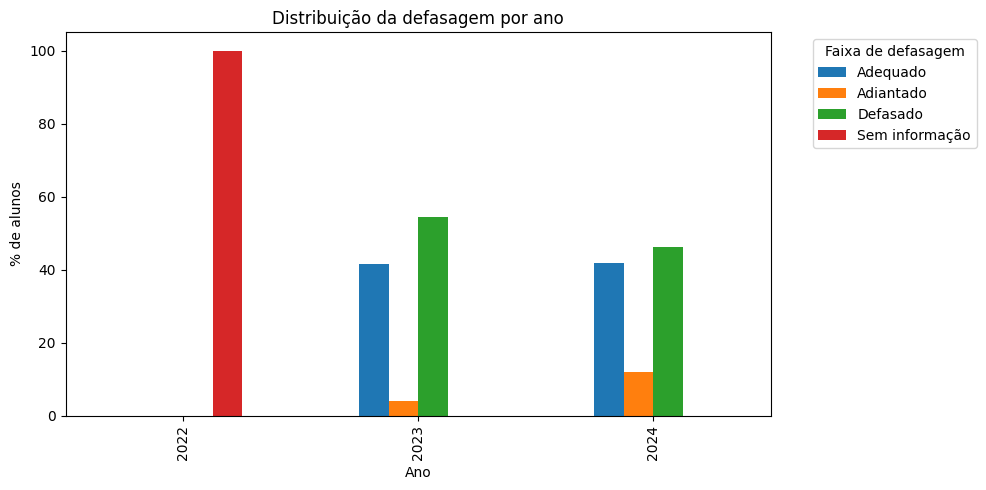

In [42]:
ian_resumo = (
    base.groupby(["ANO", "FAIXA_DEFASAGEM"])
    .agg(
        alunos=("RA", "nunique"),
        ian_medio=("IAN", "mean"),
        defasagem_media=("DEFASAGEM", "mean")
    )
    .reset_index()
)

ian_resumo["pct_ano"] = ian_resumo["alunos"] / ian_resumo.groupby("ANO")["alunos"].transform("sum")
display(ian_resumo.sort_values(["ANO", "FAIXA_DEFASAGEM"]))

tabela_defasagem = ian_resumo.pivot(index="ANO", columns="FAIXA_DEFASAGEM", values="pct_ano").fillna(0) * 100

tabela_defasagem.plot(kind="bar", figsize=(10, 5))
plt.title("Distribuição da defasagem por ano")
plt.ylabel("% de alunos")
plt.xlabel("Ano")
plt.legend(title="Faixa de defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_defasagem_por_ano.png", dpi=150)
plt.show()

## 9. Pergunta 2 — Desempenho acadêmico (IDA)

🚀 Iniciando Tech Challenge - Passos Mágicos
📁 BASE_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos
📁 RAW_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\raw
📁 PROCESSED_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\processed
📁 OUTPUTS_DIR: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs

📖 Procurando arquivos em data/raw...

📄 Arquivos encontrados:
 - BASE DE DADOS PEDE 2024 - DATATHON.xlsx

📖 Lendo arquivo: BASE DE DADOS PEDE 2024 - DATATHON.xlsx
📚 Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
✅ Aba adicionada: PEDE2022 | Ano: 2022 | Linhas: 860
✅ Aba adicionad

,RA,FASE,TURMA,NOME,ANO_NASC,IDADE_22,GENERO,ANO_INGRESSO,INSTITUICAO_DE_ENSINO,PEDRA_20,PEDRA_21,PEDRA_22,INDE_22,CG,CF,CT,NO_AV,AVALIADOR1,REC_AV1,AVALIADOR2,REC_AV2,AVALIADOR3,REC_AV3,AVALIADOR4,REC_AV4,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,MATEM,PORTUG,INGLES,INDICADO,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFAS,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,INDE_2023,PEDRA_2023,NOME_ANONIMIZADO,DATA_DE_NASC,IDADE,IPP,MAT,POR,ING,DEFASAGEM,INDE_2024,PEDRA_2024,PEDRA_23,INDE_23,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO_INATIVO,ATIVO_INATIVO1
0,RA-1,7,A,Aluno-1,"2,003.000",19.000,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.000,18.000,10.000,4.000,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.300,4.100,5.600,Requer avaliação,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,"2,005.000",17.000,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.000,8.000,3.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.800,5.200,6.300,Sem limitações,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.000,13.000,6.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.000,7.900,5.600,Sem limitações,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,"2,005.000",17.000,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.000,15.000,7.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.800,4.500,5.600,Requer avaliação,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,"2,005.000",17.000,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.000,6.000,2.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.900,8.600,5.600,Requer avaliação,5.200,7.000,2.900,5.700,Não,Não,7.389,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



⚙️ Criando variáveis analíticas...
✅ INDE: criando a partir de ['INDE_22', 'INDE_2023', 'INDE_2024', 'INDE_23']
✅ IAA: coluna já existia
✅ IEG: coluna já existia
✅ IPS: coluna já existia
✅ IPP: coluna já existia
✅ IDA: coluna já existia
✅ IPV: coluna já existia
✅ IAN: coluna já existia
✅ DEFASAGEM: coluna já existia
✅ Coluna de gênero localizada: GENERO
✅ Coluna de instituição localizada: ESCOLA

✅ Base tratada salva em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\processed\datathon_base_tratada.csv


,RA,FASE,TURMA,NOME,ANO_NASC,IDADE_22,GENERO,ANO_INGRESSO,INSTITUICAO_DE_ENSINO,PEDRA_20,PEDRA_21,PEDRA_22,INDE_22,CG,CF,CT,NO_AV,AVALIADOR1,REC_AV1,AVALIADOR2,REC_AV2,AVALIADOR3,REC_AV3,AVALIADOR4,REC_AV4,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,MATEM,PORTUG,INGLES,INDICADO,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFAS,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,INDE_2023,PEDRA_2023,NOME_ANONIMIZADO,DATA_DE_NASC,IDADE,IPP,MAT,POR,ING,DEFASAGEM,INDE_2024,PEDRA_2024,PEDRA_23,INDE_23,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO_INATIVO,ATIVO_INATIVO1,INDE,RISCO_DEFASAGEM,FAIXA_INDE,FAIXA_IAA,FAIXA_IEG,FAIXA_IPS,FAIXA_IPP,FAIXA_IDA,FAIXA_IPV,FAIXA_IAN,FAIXA_DEFASAGEM,DIF_AUTOAVALIACAO_DESEMPENHO,DIF_ENGAJAMENTO_DESEMPENHO,DIF_PSICOPEDAGOGICO_NIVEL,MEDIA_INDICADORES_SEM_IAN,QTD_INDICADORES_ABAIXO_5,QTD_INDICADORES_ABAIXO_7,INSTITUICAO_ENSINO
0,RA-1,7,A,Aluno-1,"2,003.000",19.000,Feminino,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.000,18.000,10.000,4.000,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.300,4.100,5.600,Requer avaliação,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.783,1,Médio,Bom,Baixo,Médio,Sem informação,Baixo,Bom,Médio,Sem informação,4.300,0.100,NaN,5.856,2,3,NaN
1,RA-2,7,A,Aluno-2,"2,005.000",17.000,Feminino,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.000,8.000,3.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.800,5.200,6.300,Sem limitações,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.055,0,Bom,Excelente,Médio,Médio,Sem informação,Médio,Médio,Excelente,Sem informação,2.000,-1.600,NaN,6.776,0,4,NaN
2,RA-3,7,A,Aluno-3,"2,005.000",17.000,Feminino,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.000,13.000,6.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.000,7.900,5.600,Sem limitações,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0.000,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.591,0,Médio,Baixo,Bom,Médio,Sem informação,Médio,Bom,Excelente,Sem informação,-5.600,2.300,NaN,5.331,1,3,NaN
3,RA-4,7,A,Aluno-4,"2,005.000",17.000,Masculino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.000,15.000,7.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.800,4.500,5.600,Requer avaliação,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0.000,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.951,0,Médio,Excelente,Baixo,Médio,Sem informação,Médio,Médio,Excelente,Sem informação,3.800,-0.500,NaN,5.836,1,4,NaN
4,RA-5,7,A,Aluno-5,"2,005.000",17.000,Feminino,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.000,6.000,2.000,4.000,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.900,8.600,5.600,Requer avaliação,5.200,7.000,2.900,5.700,Não,Não,7


1. ANÁLISE DE DEFASAGEM / IAN


,ANO,IAN_medio,DEFASAGEM_media,RISCO_DEFASAGEM_pct,alunos
0,2022,6.424,NaN,69.900,860
1,2023,7.244,-0.655,54.400,1014
2,2024,7.684,-0.409,46.200,1156


📊 Gráfico salvo: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\graficos\01_evolucao_ian.png


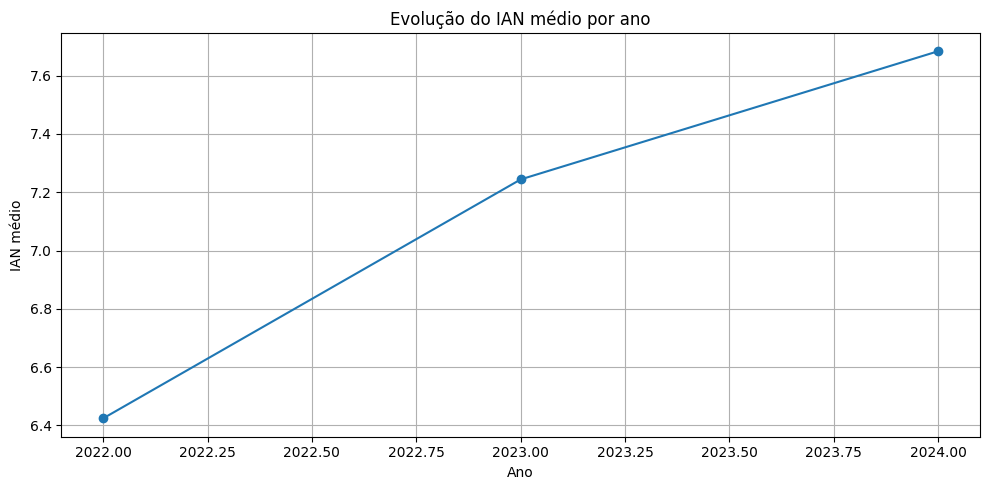


2. ANÁLISE DE DESEMPENHO ACADÊMICO / IDA
⚠️ Coluna de desempenho não encontrada e será ignorada: MATEMATICA
⚠️ Coluna de desempenho não encontrada e será ignorada: PORTUGUES


,ANO,alunos,IDA_medio,INGLES_medio
0,2022,860,6.093,5.881
1,2023,1014,6.663,NaN
2,2024,1156,6.351,NaN


📊 Gráfico salvo: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\graficos\02_evolucao_desempenho.png


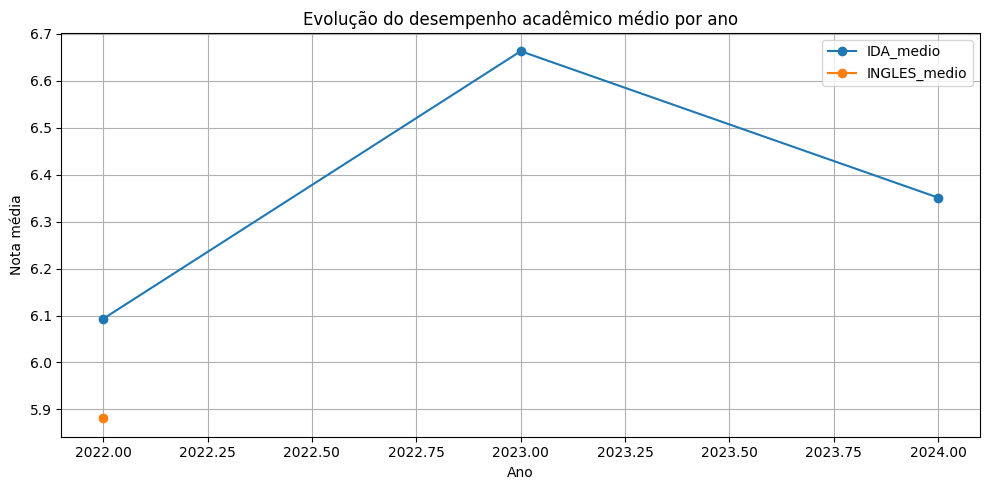


3. ENGAJAMENTO / IEG


,IEG,IDA,IPV,INDE,IAA,IPS,IPP,IAN
IEG,1.000,0.539,0.558,0.586,0.133,-0.046,0.329,-0.060
IDA,0.539,1.000,0.557,0.702,0.115,0.022,0.369,0.118
IPV,0.558,0.557,1.000,0.633,0.063,-0.049,0.607,0.149
INDE,0.586,0.702,0.633,1.000,0.296,0.115,0.403,0.386
IAA,0.133,0.115,0.063,0.296,1.000,0.157,0.054,0.034
IPS,-0.046,0.022,-0.049,0.115,0.157,1.000,0.064,0.005
IPP,0.329,0.369,0.607,0.403,0.054,0.064,1.000,0.123
IAN,-0.060,0.118,0.149,0.386,0.034,0.005,0.123,1.000


✅ Correlação salva em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\correlacao_indicadores.csv
📊 Gráfico salvo: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\graficos\03_ieg_x_ida.png


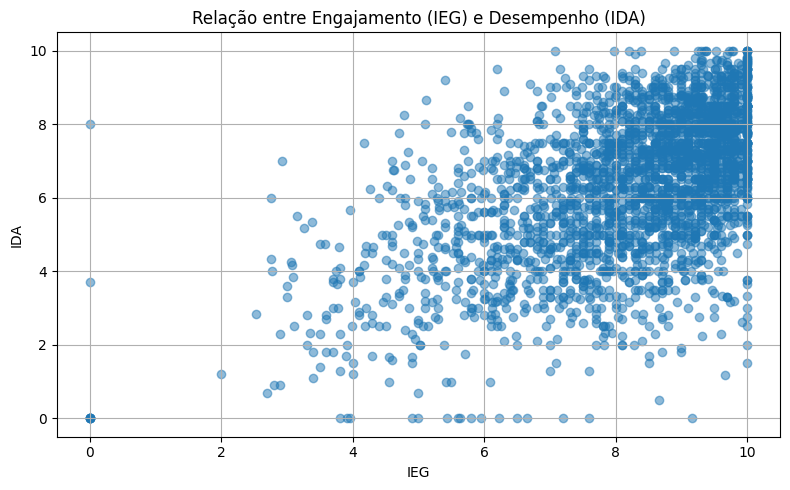


4. AUTOAVALIAÇÃO / IAA


,ANO,DIF_IAA_IDA_media,IAA_media,IDA_media
0,2022,2.182,8.274,6.093
1,2023,0.255,6.903,6.663
2,2024,2.194,8.544,6.351


📊 Gráfico salvo: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\graficos\04_autoavaliacao_x_desempenho.png


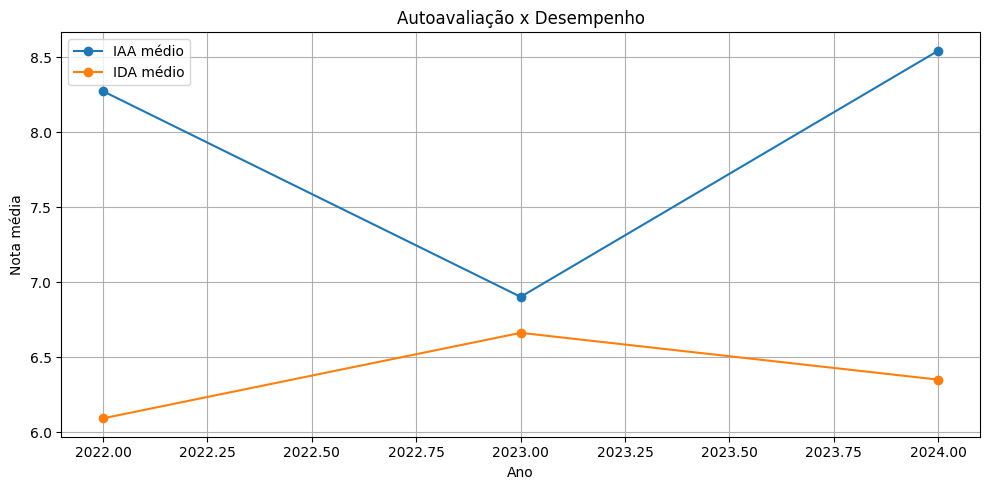


5. ASPECTOS PSICOSSOCIAIS / IPS


,ANO,IPS_medio,RISCO_DEFASAGEM_pct
0,2022,6.905,69.900
1,2023,5.120,54.400
2,2024,6.830,46.200


📊 Gráfico salvo: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\graficos\05_evolucao_ips.png


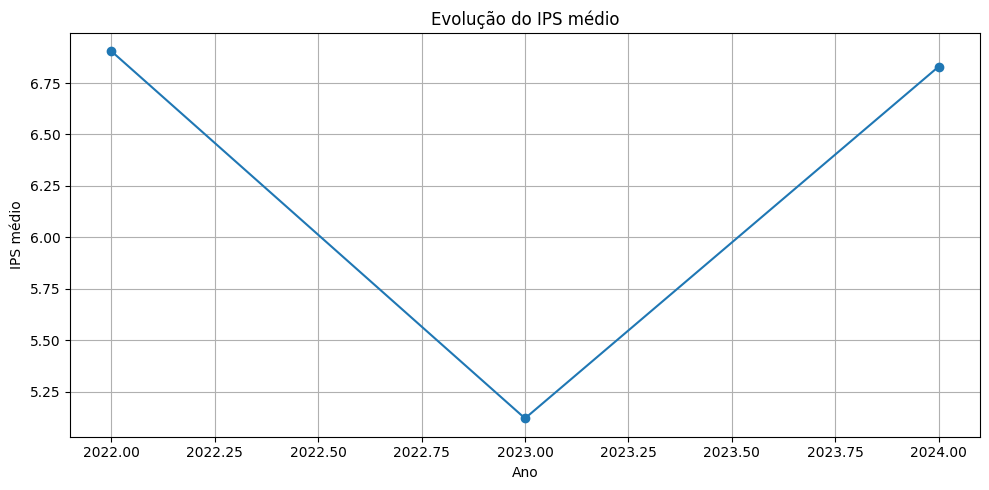


6. ASPECTOS PSICOPEDAGÓGICOS / IPP


,ANO,IPP_medio,RISCO_DEFASAGEM_pct
0,2022,NaN,69.900
1,2023,7.563,54.400
2,2024,7.548,46.200



7. PONTO DE VIRADA / IPV


,correlacao_com_IPV
IPV,1.000
INDE,0.633
IPP,0.607
IEG,0.558
IDA,0.557
IAN,0.149
IAA,0.063
IPS,-0.049



8. MULTIDIMENSIONALIDADE DOS INDICADORES


...


📌 Matriz de confusão:
[[279  57]
 [ 13 409]]

📌 Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       336
           1       0.88      0.97      0.92       422

    accuracy                           0.91       758
   macro avg       0.92      0.90      0.90       758
weighted avg       0.91      0.91      0.91       758

✅ Métricas salvas em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\metricas_modelo.csv
✅ Modelo salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\models\modelo_risco_defasagem.joblib
✅ Ranking de risco salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\ranking_alunos_mai

,variavel,importancia
11,DIF_PSICOPEDAGOGICO_NIVEL,0.548
6,MEDIA_INDICADORES_SEM_IAN,0.071
1,IEG,0.065
5,IPV,0.062
10,DIF_ENGAJAMENTO_DESEMPENHO,0.046
9,DIF_AUTOAVALIACAO_DESEMPENHO,0.046
4,IDA,0.046
0,IAA,0.032
2,IPS,0.032
3,IPP,0.027


✅ Importância das variáveis salva em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\importancia_variaveis_modelo.csv

10. EFETIVIDADE DO PROGRAMA


,ANO,alunos,INDE_medio,IDA_medio,IEG_medio,IAN_medio,IPV_medio,IPS_medio,IPP_medio,RISCO_DEFASAGEM_pct
0,2022,860,7.036,6.093,7.891,6.424,7.254,6.905,NaN,69.900
1,2023,1014,7.356,6.663,8.699,7.244,8.028,5.120,7.563,54.400
2,2024,1156,7.393,6.351,7.375,7.684,7.354,6.830,7.548,46.200


✅ Efetividade salva em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\efetividade_programa.csv

11. INSIGHTS E STORYTELLING
STORYTELLING GERENCIAL - PASSOS MÁGICOS

1. Contexto
A Associação Passos Mágicos atua na transformação social por meio da educação, acompanhando indicadores acadêmicos, psicossociais, psicopedagógicos e de engajamento.

2. Problema de negócio
Identificar alunos em risco de defasagem antes que a queda de desempenho se consolide, permitindo ações preventivas.

3. Principais achados
- O percentual geral de alunos classificados em risco de defasagem é de 55.68%.
- O INDE médio geral da base é de 7.28.
- O IDA médio geral é de 6.38, representando o desempenho acadêmico médio.
- A correlação entre engajamento IEG e desempenho IDA é de 0.539.
- O indicador mais associado ao ponto de virada IPV é INDE, com correlação de 0.633.
- O modelo preditivo foi treinado com su

In [43]:
# ============================================================
# TECH CHALLENGE / DATATHON - PASSOS MÁGICOS
# Script completo ajustado
# Compatível com VS Code, Jupyter Notebook e Python .py
# ============================================================

import os
import re
import glob
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURAÇÃO DE CAMINHOS
# ============================================================

def localizar_base_dir():
    """
    Localiza automaticamente a pasta principal do projeto.

    Estrutura esperada:
    tech_challenge_passos_magicos/
        data/
            raw/
            processed/
        outputs/
    """

    if "__file__" in globals():
        caminho_atual = Path(__file__).resolve()

        if caminho_atual.parent.name.lower() in ["src", "scripts", "notebooks"]:
            return caminho_atual.parent.parent

        return caminho_atual.parent

    cwd = Path(os.getcwd()).resolve()

    if cwd.name.lower() in ["notebooks", "src", "scripts"]:
        return cwd.parent

    return cwd


BASE_DIR = localizar_base_dir()

# Se quiser forçar manualmente o caminho, descomente e ajuste:
# BASE_DIR = Path(r"C:\Users\Danilo\Downloads\tech_challenge_passos_magicos")

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"
GRAFICOS_DIR = OUTPUTS_DIR / "graficos"
MODELS_DIR = BASE_DIR / "models"

for pasta in [RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR, GRAFICOS_DIR, MODELS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

print("🚀 Iniciando Tech Challenge - Passos Mágicos")
print("📁 BASE_DIR:", BASE_DIR)
print("📁 RAW_DIR:", RAW_DIR)
print("📁 PROCESSED_DIR:", PROCESSED_DIR)
print("📁 OUTPUTS_DIR:", OUTPUTS_DIR)


# ============================================================
# 2. FUNÇÕES AUXILIARES
# ============================================================

def display_df(df, nome="DataFrame"):
    try:
        display(df)
    except Exception:
        print(f"\n{nome}:")
        print(df)


def remover_acentos(texto):
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    return texto


def normalizar_texto_coluna(texto):
    texto = remover_acentos(texto)
    texto = texto.upper().strip()
    texto = texto.replace("\n", " ")
    texto = re.sub(r"\s+", "_", texto)
    texto = texto.replace("-", "_")
    texto = texto.replace("/", "_")
    texto = texto.replace("\\", "_")
    texto = texto.replace(".", "")
    texto = texto.replace("(", "")
    texto = texto.replace(")", "")
    texto = texto.replace("%", "PERC")
    texto = re.sub(r"[^A-Z0-9_]", "", texto)
    texto = re.sub(r"_+", "_", texto)
    texto = texto.strip("_")
    return texto


def converter_numero_seguro(valor):
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, (int, float, np.number)):
        return float(valor)

    valor = str(valor).strip()

    if valor == "" or valor.lower() in ["nan", "none", "null"]:
        return np.nan

    # Se vier com vírgula decimal BR
    if "," in valor:
        valor = valor.replace(".", "").replace(",", ".")
    else:
        valor = valor.replace(",", ".")

    try:
        return float(valor)
    except Exception:
        return np.nan


def identificar_ano(texto):
    texto = str(texto)
    achou = re.search(r"20(22|23|24)", texto)

    if achou:
        return int(achou.group())

    return None


def localizar_coluna_por_opcoes(df, opcoes):
    mapa_colunas = {normalizar_texto_coluna(c): c for c in df.columns}

    for opcao in opcoes:
        opcao_norm = normalizar_texto_coluna(opcao)

        if opcao_norm in mapa_colunas:
            return mapa_colunas[opcao_norm]

    for col_norm, col_original in mapa_colunas.items():
        for opcao in opcoes:
            opcao_norm = normalizar_texto_coluna(opcao)

            if opcao_norm in col_norm:
                return col_original

    return None


def localizar_colunas_indicador(df, indicador):
    cols = []
    indicador_norm = normalizar_texto_coluna(indicador)

    ignorar = [
        "CONCEITO",
        "PEDRA",
        "NIVEL",
        "FAIXA",
        "CATEGORIA",
        "STATUS",
        "SITUACAO"
    ]

    for col in df.columns:
        col_norm = normalizar_texto_coluna(col)

        if col_norm == indicador_norm:
            cols.append(col)
            continue

        if col_norm.startswith(indicador_norm + "_"):
            if not any(x in col_norm for x in ignorar):
                cols.append(col)
            continue

        if col_norm.endswith("_" + indicador_norm):
            if not any(x in col_norm for x in ignorar):
                cols.append(col)
            continue

        if indicador_norm in col_norm:
            if not any(x in col_norm for x in ignorar):
                cols.append(col)

    return list(dict.fromkeys(cols))


def classificar_faixa_indicador(valor):
    if pd.isna(valor):
        return "Sem informação"

    if valor < 5:
        return "Baixo"
    elif valor < 7:
        return "Médio"
    elif valor < 8.5:
        return "Bom"
    else:
        return "Excelente"


def classificar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"

    if valor < 0:
        return "Defasado"
    elif valor == 0:
        return "Adequado"
    else:
        return "Adiantado"


def definir_risco_defasagem(row):
    defasagem = row.get("DEFASAGEM", np.nan)
    ian = row.get("IAN", np.nan)

    try:
        if pd.notna(defasagem) and float(defasagem) < 0:
            return 1
    except Exception:
        pass

    try:
        if pd.notna(ian) and float(ian) <= 5:
            return 1
    except Exception:
        pass

    return 0


def salvar_grafico(nome_arquivo):
    caminho = GRAFICOS_DIR / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    print("📊 Gráfico salvo:", caminho)


# ============================================================
# 3. LEITURA E CONSOLIDAÇÃO DAS BASES
# ============================================================

print("\n📖 Procurando arquivos em data/raw...")

arquivos_encontrados = []

for extensao in ["*.xlsx", "*.xls", "*.csv"]:
    arquivos_encontrados.extend(glob.glob(str(RAW_DIR / extensao)))

print("\n📄 Arquivos encontrados:")
for arq in arquivos_encontrados:
    print(" -", Path(arq).name)

if not arquivos_encontrados:
    raise FileNotFoundError(
        f"Nenhum arquivo Excel ou CSV encontrado em:\n{RAW_DIR}\n\n"
        "Coloque os arquivos PEDE 2022, 2023 e 2024 dentro de data/raw."
    )


def normalizar_base_ano(df, ano):
    df = df.copy()

    df.columns = [normalizar_texto_coluna(c) for c in df.columns]

    df = df.dropna(axis=1, how="all")
    df = df.dropna(axis=0, how="all")

    df["ANO"] = ano

    return df


lista_bases = []

for arquivo in arquivos_encontrados:
    arquivo = Path(arquivo)
    nome_arquivo = arquivo.name
    extensao = arquivo.suffix.lower()

    print("\n" + "=" * 80)
    print("📖 Lendo arquivo:", nome_arquivo)

    ano_arquivo = identificar_ano(nome_arquivo)

    try:
        if extensao in [".xlsx", ".xls"]:
            xls = pd.ExcelFile(arquivo)
            print("📚 Abas encontradas:", xls.sheet_names)

            for aba in xls.sheet_names:
                ano_aba = identificar_ano(aba)
                ano_final = ano_aba or ano_arquivo

                if ano_final is None:
                    print(f"⚠️ Aba ignorada sem ano identificado: {aba}")
                    continue

                df_aba = pd.read_excel(arquivo, sheet_name=aba)

                if df_aba.empty:
                    print(f"⚠️ Aba vazia ignorada: {aba}")
                    continue

                df_norm = normalizar_base_ano(df_aba, ano_final)
                lista_bases.append(df_norm)

                print(f"✅ Aba adicionada: {aba} | Ano: {ano_final} | Linhas: {len(df_norm):,}")

        elif extensao == ".csv":
            ano_final = ano_arquivo

            if ano_final is None:
                print(f"⚠️ CSV ignorado sem ano identificado no nome: {nome_arquivo}")
                continue

            try:
                df_csv = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")
            except Exception:
                df_csv = pd.read_csv(arquivo, sep=",", encoding="utf-8-sig")

            if df_csv.empty:
                print(f"⚠️ CSV vazio ignorado: {nome_arquivo}")
                continue

            df_norm = normalizar_base_ano(df_csv, ano_final)
            lista_bases.append(df_norm)

            print(f"✅ CSV adicionado | Ano: {ano_final} | Linhas: {len(df_norm):,}")

    except Exception as e:
        print(f"❌ Erro ao ler {nome_arquivo}: {e}")


if not lista_bases:
    raise ValueError(
        "Nenhuma base válida foi encontrada.\n\n"
        "Verifique:\n"
        "1. Os arquivos estão em data/raw.\n"
        "2. O nome do arquivo ou da aba contém 2022, 2023 ou 2024.\n"
        "3. As abas não estão vazias."
    )

base = pd.concat(lista_bases, ignore_index=True)

print("\n✅ Base consolidada com sucesso!")
print("📊 Linhas:", len(base))
print("📊 Colunas:", len(base.columns))
print("📅 Anos encontrados:", sorted(base["ANO"].dropna().unique()))

print("\n📌 Colunas da base consolidada:")
for c in base.columns:
    print(" -", c)

display_df(base.head(), "Amostra inicial")


# ============================================================
# 4. FEATURE ENGINEERING / VARIÁVEIS ANALÍTICAS
# ============================================================

print("\n⚙️ Criando variáveis analíticas...")

indicadores_padrao = [
    "INDE",
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "IPV",
    "IAN",
    "DEFASAGEM"
]

for indicador in indicadores_padrao:

    if indicador in base.columns:
        base[indicador] = base[indicador].apply(converter_numero_seguro)
        print(f"✅ {indicador}: coluna já existia")
        continue

    colunas_encontradas = localizar_colunas_indicador(base, indicador)

    if colunas_encontradas:
        print(f"✅ {indicador}: criando a partir de {colunas_encontradas}")

        temp = base[colunas_encontradas].copy()

        for c in temp.columns:
            temp[c] = temp[c].apply(converter_numero_seguro)

        base[indicador] = temp.bfill(axis=1).iloc[:, 0]

    else:
        print(f"⚠️ {indicador}: não encontrado")


# ------------------------------------------------------------
# DEFASAGEM
# ------------------------------------------------------------

if "DEFASAGEM" not in base.columns or base["DEFASAGEM"].isna().all():

    possiveis_fase_atual = [
        c for c in base.columns
        if "FASE" in normalizar_texto_coluna(c)
        and "IDEAL" not in normalizar_texto_coluna(c)
        and "TURMA" not in normalizar_texto_coluna(c)
    ]

    possiveis_fase_ideal = [
        c for c in base.columns
        if "FASE" in normalizar_texto_coluna(c)
        and "IDEAL" in normalizar_texto_coluna(c)
    ]

    if possiveis_fase_atual and possiveis_fase_ideal:
        col_fase_atual = possiveis_fase_atual[0]
        col_fase_ideal = possiveis_fase_ideal[0]

        print(f"🧮 Calculando DEFASAGEM usando {col_fase_atual} e {col_fase_ideal}")

        fase_atual = base[col_fase_atual].apply(converter_numero_seguro)
        fase_ideal = base[col_fase_ideal].apply(converter_numero_seguro)

        base["DEFASAGEM"] = fase_atual - fase_ideal
    else:
        print("⚠️ DEFASAGEM não encontrada e não foi possível calcular por fase.")


# ------------------------------------------------------------
# RISCO
# ------------------------------------------------------------

base["RISCO_DEFASAGEM"] = base.apply(definir_risco_defasagem, axis=1)


# ------------------------------------------------------------
# FAIXAS
# ------------------------------------------------------------

for col in ["INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]:
    if col in base.columns:
        base[f"FAIXA_{col}"] = base[col].apply(classificar_faixa_indicador)

if "DEFASAGEM" in base.columns:
    base["FAIXA_DEFASAGEM"] = base["DEFASAGEM"].apply(classificar_defasagem)


# ------------------------------------------------------------
# VARIÁVEIS COMPARATIVAS
# ------------------------------------------------------------

if "IAA" in base.columns and "IDA" in base.columns:
    base["DIF_AUTOAVALIACAO_DESEMPENHO"] = base["IAA"] - base["IDA"]

if "IEG" in base.columns and "IDA" in base.columns:
    base["DIF_ENGAJAMENTO_DESEMPENHO"] = base["IEG"] - base["IDA"]

if "IPP" in base.columns and "IAN" in base.columns:
    base["DIF_PSICOPEDAGOGICO_NIVEL"] = base["IPP"] - base["IAN"]


# ------------------------------------------------------------
# INDICADORES MULTIDIMENSIONAIS
# ------------------------------------------------------------

indicadores_sem_ian = [
    c for c in ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV"]
    if c in base.columns
]

if indicadores_sem_ian:
    base["MEDIA_INDICADORES_SEM_IAN"] = base[indicadores_sem_ian].mean(axis=1)
    base["QTD_INDICADORES_ABAIXO_5"] = (base[indicadores_sem_ian] < 5).sum(axis=1)
    base["QTD_INDICADORES_ABAIXO_7"] = (base[indicadores_sem_ian] < 7).sum(axis=1)


# ------------------------------------------------------------
# GÊNERO
# ------------------------------------------------------------

col_genero = localizar_coluna_por_opcoes(
    base,
    [
        "GENERO",
        "GÊNERO",
        "SEXO",
        "GENERO_ALUNO",
        "GÊNERO_ALUNO"
    ]
)

if col_genero:
    print(f"✅ Coluna de gênero localizada: {col_genero}")

    base["GENERO"] = (
        base[col_genero]
        .astype(str)
        .str.strip()
        .replace({
            "Menina": "Feminino",
            "Menino": "Masculino",
            "F": "Feminino",
            "M": "Masculino",
            "f": "Feminino",
            "m": "Masculino",
            "Feminino": "Feminino",
            "Masculino": "Masculino",
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )
else:
    print("⚠️ Coluna GENERO/SEXO não encontrada. Criando como Não informado.")
    base["GENERO"] = "Não informado"


# ------------------------------------------------------------
# INSTITUIÇÃO DE ENSINO
# ------------------------------------------------------------

col_instituicao = localizar_coluna_por_opcoes(
    base,
    [
        "INSTITUICAO_ENSINO",
        "INSTITUIÇÃO_ENSINO",
        "INSTITUICAO",
        "INSTITUIÇÃO",
        "ESCOLA",
        "TIPO_ESCOLA",
        "TIPO_DE_ESCOLA",
        "REDE_ENSINO",
        "REDE_DE_ENSINO"
    ]
)

if col_instituicao:
    print(f"✅ Coluna de instituição localizada: {col_instituicao}")

    base["INSTITUICAO_ENSINO"] = (
        base[col_instituicao]
        .astype(str)
        .str.strip()
        .replace({
            "Escola Pública": "Pública",
            "Escola Publica": "Pública",
            "Pública": "Pública",
            "Publica": "Pública",
            "pública": "Pública",
            "publica": "Pública",
            "Escola Particular": "Particular",
            "Particular": "Particular",
            "Privada": "Particular",
            "privada": "Particular",
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )
else:
    print("⚠️ Coluna de instituição não encontrada. Criando como Não informado.")
    base["INSTITUICAO_ENSINO"] = "Não informado"


arquivo_base_tratada = PROCESSED_DIR / "datathon_base_tratada.csv"

base.to_csv(
    arquivo_base_tratada,
    sep=";",
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print("\n✅ Base tratada salva em:", arquivo_base_tratada)
display_df(base.head(), "Base tratada")


# ============================================================
# 5. ANÁLISE 1 - ADEQUAÇÃO DO NÍVEL / IAN
# ============================================================

print("\n" + "=" * 80)
print("1. ANÁLISE DE DEFASAGEM / IAN")

agg_ian = {}

if "IAN" in base.columns:
    agg_ian["IAN_medio"] = ("IAN", "mean")

if "DEFASAGEM" in base.columns:
    agg_ian["DEFASAGEM_media"] = ("DEFASAGEM", "mean")

agg_ian["RISCO_DEFASAGEM_pct"] = ("RISCO_DEFASAGEM", "mean")
agg_ian["alunos"] = ("ANO", "size")

ian_resumo = (
    base.groupby("ANO")
    .agg(**agg_ian)
    .round(3)
    .reset_index()
)

ian_resumo["RISCO_DEFASAGEM_pct"] = (ian_resumo["RISCO_DEFASAGEM_pct"] * 100).round(2)

display_df(ian_resumo, "Resumo IAN")

if "IAN_medio" in ian_resumo.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(ian_resumo["ANO"], ian_resumo["IAN_medio"], marker="o")
    plt.title("Evolução do IAN médio por ano")
    plt.xlabel("Ano")
    plt.ylabel("IAN médio")
    plt.grid(True)
    salvar_grafico("01_evolucao_ian.png")
    plt.show()


# ============================================================
# 6. ANÁLISE 2 - DESEMPENHO ACADÊMICO / IDA
# ============================================================

print("\n" + "=" * 80)
print("2. ANÁLISE DE DESEMPENHO ACADÊMICO / IDA")

possiveis_colunas_aluno = ["RA", "ID_ALUNO", "NOME", "ALUNO"]
coluna_aluno = None

for col in possiveis_colunas_aluno:
    if col in base.columns:
        coluna_aluno = col
        break

colunas_desempenho = []

for col in ["IDA", "MATEMATICA", "PORTUGUES", "INGLES"]:
    if col in base.columns:
        colunas_desempenho.append(col)
    else:
        print(f"⚠️ Coluna de desempenho não encontrada e será ignorada: {col}")

if colunas_desempenho:
    agg_dict = {}

    if coluna_aluno:
        agg_dict["alunos"] = (coluna_aluno, "nunique")
    else:
        agg_dict["alunos"] = ("ANO", "size")

    for col in colunas_desempenho:
        agg_dict[f"{col}_medio"] = (col, "mean")

    ida_resumo = (
        base.groupby("ANO")
        .agg(**agg_dict)
        .round(3)
        .reset_index()
    )

    display_df(ida_resumo, "Resumo IDA")

    colunas_grafico = [f"{col}_medio" for col in colunas_desempenho]

    plt.figure(figsize=(10, 5))
    for col in colunas_grafico:
        plt.plot(ida_resumo["ANO"], ida_resumo[col], marker="o", label=col)

    plt.title("Evolução do desempenho acadêmico médio por ano")
    plt.xlabel("Ano")
    plt.ylabel("Nota média")
    plt.grid(True)
    plt.legend()
    salvar_grafico("02_evolucao_desempenho.png")
    plt.show()
else:
    print("⚠️ Nenhuma coluna de desempenho acadêmico encontrada.")


# ============================================================
# 7. ANÁLISE 3 - ENGAJAMENTO / IEG X IDA X IPV
# ============================================================

print("\n" + "=" * 80)
print("3. ENGAJAMENTO / IEG")

cols_corr = [c for c in ["IEG", "IDA", "IPV", "INDE", "IAA", "IPS", "IPP", "IAN"] if c in base.columns]

if len(cols_corr) >= 2:
    correlacao = base[cols_corr].corr().round(3)
    display_df(correlacao, "Correlação dos indicadores")

    arquivo_corr = OUTPUTS_DIR / "correlacao_indicadores.csv"
    correlacao.to_csv(arquivo_corr, sep=";", encoding="utf-8-sig", decimal=",")
    print("✅ Correlação salva em:", arquivo_corr)

    if "IEG" in base.columns and "IDA" in base.columns:
        plt.figure(figsize=(8, 5))
        plt.scatter(base["IEG"], base["IDA"], alpha=0.5)
        plt.title("Relação entre Engajamento (IEG) e Desempenho (IDA)")
        plt.xlabel("IEG")
        plt.ylabel("IDA")
        plt.grid(True)
        salvar_grafico("03_ieg_x_ida.png")
        plt.show()
else:
    print("⚠️ Não há indicadores suficientes para correlação.")


# ============================================================
# 8. ANÁLISE 4 - AUTOAVALIAÇÃO / IAA
# ============================================================

print("\n" + "=" * 80)
print("4. AUTOAVALIAÇÃO / IAA")

if "DIF_AUTOAVALIACAO_DESEMPENHO" in base.columns:
    auto_resumo = (
        base.groupby("ANO")
        .agg(
            DIF_IAA_IDA_media=("DIF_AUTOAVALIACAO_DESEMPENHO", "mean"),
            IAA_media=("IAA", "mean"),
            IDA_media=("IDA", "mean")
        )
        .round(3)
        .reset_index()
    )

    display_df(auto_resumo, "Resumo autoavaliação")

    plt.figure(figsize=(10, 5))
    plt.plot(auto_resumo["ANO"], auto_resumo["IAA_media"], marker="o", label="IAA médio")
    plt.plot(auto_resumo["ANO"], auto_resumo["IDA_media"], marker="o", label="IDA médio")
    plt.title("Autoavaliação x Desempenho")
    plt.xlabel("Ano")
    plt.ylabel("Nota média")
    plt.grid(True)
    plt.legend()
    salvar_grafico("04_autoavaliacao_x_desempenho.png")
    plt.show()
else:
    print("⚠️ Não foi possível avaliar autoavaliação, pois IAA ou IDA não existe.")


# ============================================================
# 9. ANÁLISE 5 - ASPECTOS PSICOSSOCIAIS / IPS
# ============================================================

print("\n" + "=" * 80)
print("5. ASPECTOS PSICOSSOCIAIS / IPS")

if "IPS" in base.columns:
    ips_resumo = (
        base.groupby("ANO")
        .agg(
            IPS_medio=("IPS", "mean"),
            RISCO_DEFASAGEM_pct=("RISCO_DEFASAGEM", "mean")
        )
        .round(3)
        .reset_index()
    )

    ips_resumo["RISCO_DEFASAGEM_pct"] = (ips_resumo["RISCO_DEFASAGEM_pct"] * 100).round(2)

    display_df(ips_resumo, "Resumo IPS")

    plt.figure(figsize=(10, 5))
    plt.plot(ips_resumo["ANO"], ips_resumo["IPS_medio"], marker="o")
    plt.title("Evolução do IPS médio")
    plt.xlabel("Ano")
    plt.ylabel("IPS médio")
    plt.grid(True)
    salvar_grafico("05_evolucao_ips.png")
    plt.show()
else:
    print("⚠️ Coluna IPS não encontrada.")


# ============================================================
# 10. ANÁLISE 6 - ASPECTOS PSICOPEDAGÓGICOS / IPP
# ============================================================

print("\n" + "=" * 80)
print("6. ASPECTOS PSICOPEDAGÓGICOS / IPP")

if "IPP" in base.columns:
    ipp_resumo = (
        base.groupby("ANO")
        .agg(
            IPP_medio=("IPP", "mean"),
            RISCO_DEFASAGEM_pct=("RISCO_DEFASAGEM", "mean")
        )
        .round(3)
        .reset_index()
    )

    ipp_resumo["RISCO_DEFASAGEM_pct"] = (ipp_resumo["RISCO_DEFASAGEM_pct"] * 100).round(2)

    display_df(ipp_resumo, "Resumo IPP")
else:
    print("⚠️ Coluna IPP não encontrada.")


# ============================================================
# 11. ANÁLISE 7 - PONTO DE VIRADA / IPV
# ============================================================

print("\n" + "=" * 80)
print("7. PONTO DE VIRADA / IPV")

if "IPV" in base.columns:
    cols_ipv = [c for c in ["IDA", "IEG", "IPS", "IPP", "IAA", "IAN", "INDE", "IPV"] if c in base.columns]

    if len(cols_ipv) >= 2:
        corr_ipv = base[cols_ipv].corr()["IPV"].sort_values(ascending=False).round(3)
        display_df(corr_ipv.to_frame("correlacao_com_IPV"), "Correlação com IPV")
else:
    print("⚠️ Coluna IPV não encontrada.")


# ============================================================
# 12. ANÁLISE 8 - MULTIDIMENSIONALIDADE / INDE
# ============================================================

print("\n" + "=" * 80)
print("8. MULTIDIMENSIONALIDADE DOS INDICADORES")

if "INDE" in base.columns:
    cols_inde = [c for c in ["IDA", "IEG", "IPS", "IPP", "IAA", "IPV", "IAN", "INDE"] if c in base.columns]

    if len(cols_inde) >= 2:
        corr_inde = base[cols_inde].corr()["INDE"].sort_values(ascending=False).round(3)
        display_df(corr_inde.to_frame("correlacao_com_INDE"), "Correlação com INDE")
else:
    print("⚠️ Coluna INDE não encontrada.")


# ============================================================
# 13. MODELO PREDITIVO - RISCO DE DEFASAGEM
# ============================================================

print("\n" + "=" * 80)
print("9. MODELO PREDITIVO DE RISCO DE DEFASAGEM")

modelo_treinado = False

try:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        roc_auc_score,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
    )
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    import joblib

    features_candidatas = [
        "IAA",
        "IEG",
        "IPS",
        "IPP",
        "IDA",
        "IPV",
        "MEDIA_INDICADORES_SEM_IAN",
        "QTD_INDICADORES_ABAIXO_5",
        "QTD_INDICADORES_ABAIXO_7",
        "DIF_AUTOAVALIACAO_DESEMPENHO",
        "DIF_ENGAJAMENTO_DESEMPENHO",
        "DIF_PSICOPEDAGOGICO_NIVEL"
    ]

    # Não usamos IAN nem DEFASAGEM como entrada para evitar vazamento do alvo.
    features_modelo = [c for c in features_candidatas if c in base.columns]

    if len(features_modelo) < 2:
        print("⚠️ Poucas variáveis disponíveis para treinar o modelo.")
    elif base["RISCO_DEFASAGEM"].nunique() < 2:
        print("⚠️ O alvo RISCO_DEFASAGEM possui apenas uma classe. Modelo não será treinado.")
    else:
        dados_modelo = base[features_modelo + ["RISCO_DEFASAGEM"]].copy()

        for c in features_modelo:
            dados_modelo[c] = dados_modelo[c].apply(converter_numero_seguro)

        X = dados_modelo[features_modelo]
        y = dados_modelo["RISCO_DEFASAGEM"].astype(int)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=42,
            stratify=y
        )

        modelo = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("rf", RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    class_weight="balanced",
                    max_depth=None
                ))
            ]
        )

        modelo.fit(X_train, y_train)

        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

        metricas = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob)
        }

        metricas_df = pd.DataFrame([metricas]).round(4)
        display_df(metricas_df, "Métricas do modelo")

        print("\n📌 Matriz de confusão:")
        print(confusion_matrix(y_test, y_pred))

        print("\n📌 Relatório de classificação:")
        print(classification_report(y_test, y_pred, zero_division=0))

        arquivo_metricas = OUTPUTS_DIR / "metricas_modelo.csv"
        metricas_df.to_csv(arquivo_metricas, sep=";", index=False, encoding="utf-8-sig", decimal=",")
        print("✅ Métricas salvas em:", arquivo_metricas)

        arquivo_modelo = MODELS_DIR / "modelo_risco_defasagem.joblib"
        joblib.dump(
            {
                "modelo": modelo,
                "features": features_modelo
            },
            arquivo_modelo
        )
        print("✅ Modelo salvo em:", arquivo_modelo)

        base["PROB_RISCO_DEFASAGEM"] = modelo.predict_proba(base[features_modelo])[:, 1]

        ranking_risco = (
            base.sort_values("PROB_RISCO_DEFASAGEM", ascending=False)
            .head(50)
            .copy()
        )

        arquivo_ranking = OUTPUTS_DIR / "ranking_alunos_maior_risco.csv"
        ranking_risco.to_csv(arquivo_ranking, sep=";", index=False, encoding="utf-8-sig", decimal=",")
        print("✅ Ranking de risco salvo em:", arquivo_ranking)

        modelo_treinado = True

        importancias = modelo.named_steps["rf"].feature_importances_
        importancia_df = (
            pd.DataFrame({
                "variavel": features_modelo,
                "importancia": importancias
            })
            .sort_values("importancia", ascending=False)
            .round(4)
        )

        display_df(importancia_df, "Importância das variáveis")

        arquivo_importancia = OUTPUTS_DIR / "importancia_variaveis_modelo.csv"
        importancia_df.to_csv(arquivo_importancia, sep=";", index=False, encoding="utf-8-sig", decimal=",")
        print("✅ Importância das variáveis salva em:", arquivo_importancia)

except Exception as e:
    print("⚠️ Erro ao treinar modelo:")
    print(e)


# ============================================================
# 14. EFETIVIDADE DO PROGRAMA
# ============================================================

print("\n" + "=" * 80)
print("10. EFETIVIDADE DO PROGRAMA")

colunas_efetividade = [c for c in ["INDE", "IDA", "IEG", "IAN", "IPV", "IPS", "IPP"] if c in base.columns]

if colunas_efetividade:
    agg_efetividade = {"alunos": ("ANO", "size")}

    for col in colunas_efetividade:
        agg_efetividade[f"{col}_medio"] = (col, "mean")

    agg_efetividade["RISCO_DEFASAGEM_pct"] = ("RISCO_DEFASAGEM", "mean")

    efetividade = (
        base.groupby("ANO")
        .agg(**agg_efetividade)
        .round(3)
        .reset_index()
    )

    efetividade["RISCO_DEFASAGEM_pct"] = (efetividade["RISCO_DEFASAGEM_pct"] * 100).round(2)

    display_df(efetividade, "Efetividade do programa")

    arquivo_efetividade = OUTPUTS_DIR / "efetividade_programa.csv"
    efetividade.to_csv(arquivo_efetividade, sep=";", index=False, encoding="utf-8-sig", decimal=",")
    print("✅ Efetividade salva em:", arquivo_efetividade)
else:
    print("⚠️ Nenhum indicador disponível para análise de efetividade.")


# ============================================================
# 15. INSIGHTS AUTOMÁTICOS
# ============================================================

print("\n" + "=" * 80)
print("11. INSIGHTS E STORYTELLING")

insights = []

if "RISCO_DEFASAGEM" in base.columns:
    risco_geral = base["RISCO_DEFASAGEM"].mean() * 100
    insights.append(f"O percentual geral de alunos classificados em risco de defasagem é de {risco_geral:.2f}%.")

if "INDE" in base.columns:
    inde_medio = base["INDE"].mean()
    insights.append(f"O INDE médio geral da base é de {inde_medio:.2f}.")

if "IDA" in base.columns:
    ida_medio = base["IDA"].mean()
    insights.append(f"O IDA médio geral é de {ida_medio:.2f}, representando o desempenho acadêmico médio.")

if "IEG" in base.columns and "IDA" in base.columns:
    corr_ieg_ida = base[["IEG", "IDA"]].corr().iloc[0, 1]
    insights.append(f"A correlação entre engajamento IEG e desempenho IDA é de {corr_ieg_ida:.3f}.")

if "IPV" in base.columns and len(cols_corr) >= 2:
    corr_ipv = base[cols_corr].corr()["IPV"].drop("IPV", errors="ignore").sort_values(ascending=False)
    if not corr_ipv.empty:
        insights.append(f"O indicador mais associado ao ponto de virada IPV é {corr_ipv.index[0]}, com correlação de {corr_ipv.iloc[0]:.3f}.")

if modelo_treinado:
    insights.append("O modelo preditivo foi treinado com sucesso e pode estimar a probabilidade de risco de defasagem para cada aluno.")

roteiro = [
    "STORYTELLING GERENCIAL - PASSOS MÁGICOS",
    "",
    "1. Contexto",
    "A Associação Passos Mágicos atua na transformação social por meio da educação, acompanhando indicadores acadêmicos, psicossociais, psicopedagógicos e de engajamento.",
    "",
    "2. Problema de negócio",
    "Identificar alunos em risco de defasagem antes que a queda de desempenho se consolide, permitindo ações preventivas.",
    "",
    "3. Principais achados",
]

for insight in insights:
    roteiro.append(f"- {insight}")

roteiro.extend([
    "",
    "4. Modelo preditivo",
    "Foi construído um modelo de classificação para estimar a probabilidade de risco de defasagem. Para evitar vazamento de informação, IAN e DEFASAGEM não foram usados como variáveis de entrada.",
    "",
    "5. Recomendações",
    "- Priorizar acompanhamento dos alunos com maior probabilidade de risco.",
    "- Cruzar engajamento, desempenho acadêmico e fatores psicossociais para ações mais direcionadas.",
    "- Usar o modelo como triagem inicial, mantendo a decisão final com a equipe pedagógica.",
    "- Atualizar o modelo a cada novo ciclo de dados.",
])

arquivo_roteiro = OUTPUTS_DIR / "roteiro_storytelling.txt"

with open(arquivo_roteiro, "w", encoding="utf-8") as f:
    f.write("\n".join(roteiro))

print("\n".join(roteiro))
print("\n✅ Roteiro salvo em:", arquivo_roteiro)


# ============================================================
# 16. GERAÇÃO DO APP STREAMLIT
# ============================================================

print("\n" + "=" * 80)
print("GERANDO APP STREAMLIT")

app_streamlit = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

st.set_page_config(
    page_title="Passos Mágicos - Risco de Defasagem",
    layout="wide"
)

st.title("Passos Mágicos - Modelo Preditivo de Risco de Defasagem")
st.write("Aplicação para estimar a probabilidade de um aluno entrar em risco de defasagem.")

BASE_DIR = Path(__file__).resolve().parent
MODELO_PATH = BASE_DIR / "models" / "modelo_risco_defasagem.joblib"

if not MODELO_PATH.exists():
    st.error("Modelo não encontrado. Rode o script de treinamento antes.")
    st.stop()

pacote = joblib.load(MODELO_PATH)
modelo = pacote["modelo"]
features = pacote["features"]

st.sidebar.header("Entrada dos Indicadores")

dados = {}

for feature in features:
    dados[feature] = st.sidebar.number_input(
        feature,
        min_value=0.0,
        max_value=10.0,
        value=6.0,
        step=0.1
    )

entrada = pd.DataFrame([dados])

st.subheader("Dados informados")
st.dataframe(entrada)

prob = modelo.predict_proba(entrada)[0, 1]
pred = modelo.predict(entrada)[0]

st.subheader("Resultado")

st.metric("Probabilidade de risco de defasagem", f"{prob * 100:.2f}%")

if pred == 1:
    st.error("Aluno classificado com risco de defasagem.")
else:
    st.success("Aluno não classificado em risco de defasagem.")

st.info("O resultado deve ser usado como apoio à decisão pedagógica, não como decisão automática.")
'''

arquivo_app = BASE_DIR / "app.py"

with open(arquivo_app, "w", encoding="utf-8") as f:
    f.write(app_streamlit)

print("✅ App Streamlit salvo em:", arquivo_app)


# ============================================================
# 17. REQUIREMENTS
# ============================================================

requirements = """
pandas
numpy
openpyxl
matplotlib
scikit-learn
joblib
streamlit
"""

arquivo_req = BASE_DIR / "requirements.txt"

with open(arquivo_req, "w", encoding="utf-8") as f:
    f.write(requirements.strip())

print("✅ requirements.txt salvo em:", arquivo_req)


# ============================================================
# 18. SALVAR BASE FINAL COM PROBABILIDADE, SE EXISTIR
# ============================================================

arquivo_base_final = PROCESSED_DIR / "datathon_base_final.csv"

base.to_csv(
    arquivo_base_final,
    sep=";",
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print("\n✅ Base final salva em:", arquivo_base_final)


# ============================================================
# 19. RESUMO FINAL
# ============================================================

print("\n" + "=" * 80)
print("✅ PROCESSO CONCLUÍDO COM SUCESSO")
print("=" * 80)
print("Arquivos gerados:")
print("1. Base tratada:", arquivo_base_tratada)
print("2. Base final:", arquivo_base_final)
print("3. Outputs:", OUTPUTS_DIR)
print("4. Gráficos:", GRAFICOS_DIR)
print("5. App Streamlit:", arquivo_app)
print("6. Requirements:", arquivo_req)

if modelo_treinado:
    print("7. Modelo:", MODELS_DIR / "modelo_risco_defasagem.joblib")
else:
    print("7. Modelo não treinado por falta de variáveis ou alvo válido.")

## 10. Pergunta 3 — Engajamento nas atividades (IEG)

,IEG,IDA,IPV,INDE,IAA,IPS,IPP,IAN
IEG,1.000,0.539,0.558,0.586,0.133,-0.046,0.329,-0.060
IDA,0.539,1.000,0.557,0.702,0.115,0.022,0.369,0.118
IPV,0.558,0.557,1.000,0.633,0.063,-0.049,0.607,0.149
INDE,0.586,0.702,0.633,1.000,0.296,0.115,0.403,0.386
IAA,0.133,0.115,0.063,0.296,1.000,0.157,0.054,0.034
IPS,-0.046,0.022,-0.049,0.115,0.157,1.000,0.064,0.005
IPP,0.329,0.369,0.607,0.403,0.054,0.064,1.000,0.123
IAN,-0.060,0.118,0.149,0.386,0.034,0.005,0.123,1.000


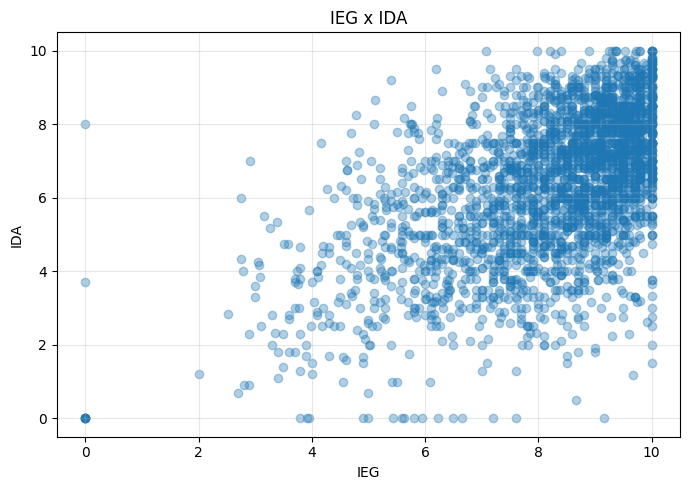

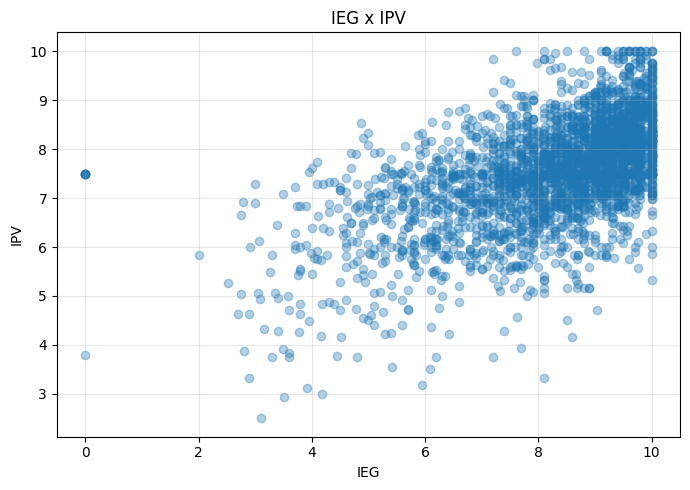

In [44]:
corr_ieg = base[["IEG", "IDA", "IPV", "INDE", "IAA", "IPS", "IPP", "IAN"]].corr(numeric_only=True).round(3)
display(corr_ieg)

plt.figure(figsize=(7, 5))
plt.scatter(base["IEG"], base["IDA"], alpha=0.35)
plt.title("IEG x IDA")
plt.xlabel("IEG")
plt.ylabel("IDA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_ieg_vs_ida.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(base["IEG"], base["IPV"], alpha=0.35)
plt.title("IEG x IPV")
plt.xlabel("IEG")
plt.ylabel("IPV")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_ieg_vs_ipv.png", dpi=150)
plt.show()

## 11. Pergunta 4 — Autoavaliação (IAA)

,ANO,IAA_medio,IDA_medio,IEG_medio,diferenca_media_IAA_IDA,alunos
0,2022,8.274,6.093,7.891,2.182,860
1,2023,6.903,6.663,8.699,0.255,1014
2,2024,8.544,6.351,7.375,2.194,1156


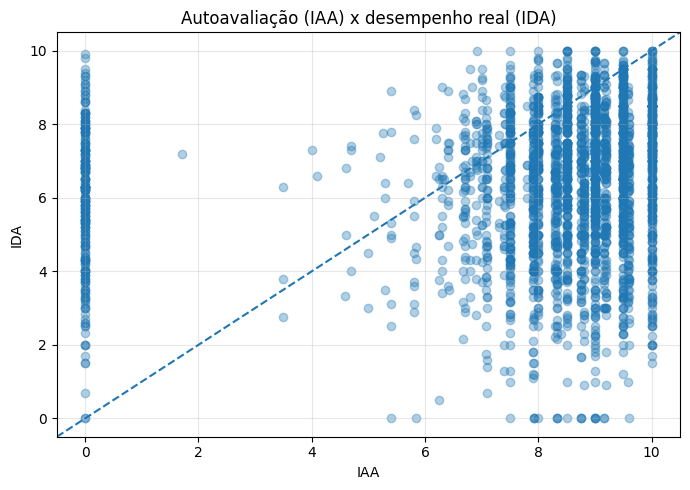

In [45]:
resumo_auto = (
    base.groupby("ANO")
    .agg(
        IAA_medio=("IAA", "mean"),
        IDA_medio=("IDA", "mean"),
        IEG_medio=("IEG", "mean"),
        diferenca_media_IAA_IDA=("DIF_AUTOAVALIACAO_DESEMPENHO", "mean"),
        alunos=("RA", "nunique")
    )
    .round(3)
    .reset_index()
)

display(resumo_auto)

plt.figure(figsize=(7, 5))
plt.scatter(base["IAA"], base["IDA"], alpha=0.35)
plt.axline((0, 0), slope=1, linestyle="--")
plt.title("Autoavaliação (IAA) x desempenho real (IDA)")
plt.xlabel("IAA")
plt.ylabel("IDA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_iaa_vs_ida.png", dpi=150)
plt.show()

## 12. Pergunta 5 — Aspectos psicossociais (IPS)

In [46]:
base_ord = base.sort_values(["RA", "ANO"]).copy()

for col in ["IDA", "IEG", "IPS", "IPP", "IAA", "IPV", "IAN", "INDE"]:
    base_ord[f"{col}_ANTERIOR"] = base_ord.groupby("RA")[col].shift(1)
    base_ord[f"VAR_{col}"] = base_ord[col] - base_ord[f"{col}_ANTERIOR"]

base_ord["QUEDA_IDA"] = (base_ord["VAR_IDA"] < -1).astype(int)
base_ord["QUEDA_IEG"] = (base_ord["VAR_IEG"] < -1).astype(int)

queda_ips = (
    base_ord.dropna(subset=["IPS_ANTERIOR"])
    .groupby("QUEDA_IDA")
    .agg(
        alunos=("RA", "nunique"),
        IPS_anterior_medio=("IPS_ANTERIOR", "mean"),
        IEG_anterior_medio=("IEG_ANTERIOR", "mean"),
        IDA_atual_medio=("IDA", "mean"),
        variacao_IDA_media=("VAR_IDA", "mean")
    )
    .round(3)
    .reset_index()
)

display(queda_ips)

queda_ieg_ips = (
    base_ord.dropna(subset=["IPS_ANTERIOR"])
    .groupby("QUEDA_IEG")
    .agg(
        alunos=("RA", "nunique"),
        IPS_anterior_medio=("IPS_ANTERIOR", "mean"),
        IEG_anterior_medio=("IEG_ANTERIOR", "mean"),
        variacao_IEG_media=("VAR_IEG", "mean")
    )
    .round(3)
    .reset_index()
)

display(queda_ieg_ips)

,QUEDA_IDA,alunos,IPS_anterior_medio,IEG_anterior_medio,IDA_atual_medio,variacao_IDA_media
0,0,713,6.073,8.524,7.020,0.652
1,1,347,5.689,8.763,5.062,-2.229


,QUEDA_IEG,alunos,IPS_anterior_medio,IEG_anterior_medio,variacao_IEG_media
0,0,731,6.110,8.541,0.271
1,1,286,5.467,8.767,-2.601


## 13. Pergunta 6 — Aspectos psicopedagógicos (IPP)

,ANO,RISCO_DEFASAGEM,alunos,IPP_medio,IAN_medio,DEFASAGEM_media,DIF_IPP_IAN_media
0,2022,0,259,NaN,10.000,NaN,NaN
1,2022,1,601,NaN,4.884,NaN,NaN
2,2023,0,462,7.665,10.000,0.102,-2.335
3,2023,1,552,7.491,4.937,-1.288,2.554
4,2024,0,622,7.688,10.000,0.252,-2.312
5,2024,1,534,7.412,4.986,-1.180,2.426


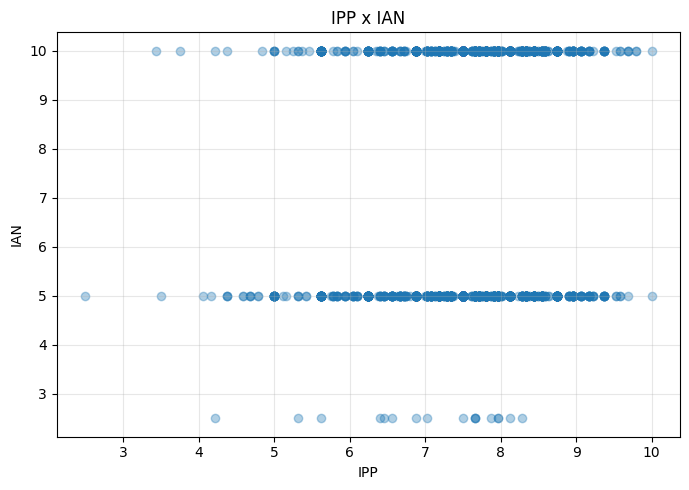

In [47]:
resumo_ipp = (
    base.groupby(["ANO", "RISCO_DEFASAGEM"])
    .agg(
        alunos=("RA", "nunique"),
        IPP_medio=("IPP", "mean"),
        IAN_medio=("IAN", "mean"),
        DEFASAGEM_media=("DEFASAGEM", "mean"),
        DIF_IPP_IAN_media=("DIF_PSICOPEDAGOGICO_NIVEL", "mean")
    )
    .round(3)
    .reset_index()
)

display(resumo_ipp)

plt.figure(figsize=(7, 5))
plt.scatter(base["IPP"], base["IAN"], alpha=0.35)
plt.title("IPP x IAN")
plt.xlabel("IPP")
plt.ylabel("IAN")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_ipp_vs_ian.png", dpi=150)
plt.show()

## 14. Pergunta 7 — Ponto de virada (IPV)

IPV          1.000
INDE         0.633
IPP          0.607
IEG          0.558
IDA          0.557
DEFASAGEM    0.157
IAN          0.149
IAA          0.063
IPS         -0.049
Name: IPV, dtype: float64

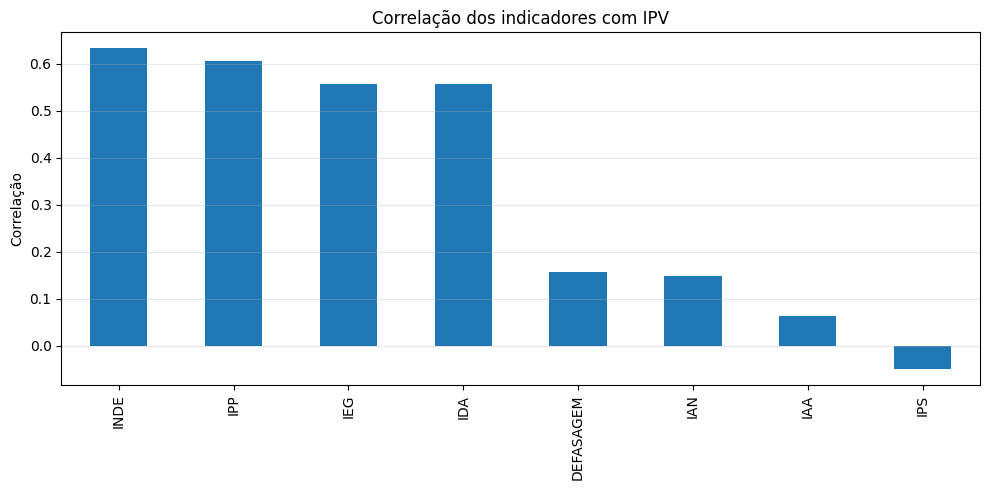

In [48]:
corr_ipv = (
    base[["IPV", "IDA", "IEG", "IAA", "IPS", "IPP", "IAN", "INDE", "DEFASAGEM"]]
    .corr(numeric_only=True)["IPV"]
    .sort_values(ascending=False)
    .round(3)
)

display(corr_ipv)

corr_ipv.drop("IPV").plot(kind="bar", figsize=(10, 5))
plt.title("Correlação dos indicadores com IPV")
plt.ylabel("Correlação")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_correlacao_ipv.png", dpi=150)
plt.show()

## 15. Pergunta 8 — Multidimensionalidade dos indicadores

In [49]:
corr_inde = (
    base[["INDE", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN"]]
    .corr(numeric_only=True)["INDE"]
    .sort_values(ascending=False)
    .round(3)
)

display(corr_inde)

base["GRUPO_MULTI"] = np.where(
    (base["IDA"] >= 7) & (base["IEG"] >= 7) & (base["IPS"] >= 7) & (base["IPP"] >= 7),
    "Todos >= 7",
    np.where(
        (base["IDA"] < 7) & (base["IEG"] < 7),
        "IDA e IEG < 7",
        np.where(
            (base["IPS"] < 7) | (base["IPP"] < 7),
            "Psico abaixo de 7",
            "Misto"
        )
    )
)

multi = (
    base.groupby("GRUPO_MULTI")
    .agg(
        alunos=("RA", "nunique"),
        INDE_medio=("INDE", "mean"),
        IDA_medio=("IDA", "mean"),
        IEG_medio=("IEG", "mean"),
        IPS_medio=("IPS", "mean"),
        IPP_medio=("IPP", "mean"),
        risco_pct=("RISCO_DEFASAGEM", "mean")
    )
    .sort_values("INDE_medio", ascending=False)
    .round(3)
    .reset_index()
)

display(multi)

INDE   1.000
IDA    0.702
IPV    0.633
IEG    0.586
IPP    0.403
IAN    0.386
IAA    0.296
IPS    0.115
Name: INDE, dtype: float64

,GRUPO_MULTI,alunos,INDE_medio,IDA_medio,IEG_medio,IPS_medio,IPP_medio,risco_pct
0,Todos >= 7,348,8.100,8.190,9.121,7.637,8.121,0.476
1,Misto,720,7.420,6.304,7.535,7.621,7.763,0.510
2,Psico abaixo de 7,901,7.342,6.622,8.725,5.060,7.424,0.571
3,IDA e IEG < 7,412,6.113,4.200,5.466,6.451,6.997,0.678


## 16. Pergunta 9 — Modelo preditivo de risco de defasagem

Alvo:

- `RISCO_DEFASAGEM = 1` quando `DEFASAGEM < 0` ou `IAN <= 5`.
- `RISCO_DEFASAGEM = 0` nos demais casos.

Para evitar vazamento de dados, **IAN, DEFASAGEM, INDE e PEDRA não entram como variáveis explicativas**.

In [50]:
df_modelo = base.copy()
target = "RISCO_DEFASAGEM"

variaveis_numericas = [
    "IDADE",
    "ANO_INGRESSO",
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "MATEMATICA",
    "PORTUGUES",
    "INGLES",
    "IPV",
    "DIF_AUTOAVALIACAO_DESEMPENHO",
    "DIF_ENGAJAMENTO_DESEMPENHO",
    "MEDIA_INDICADORES_SEM_IAN",
    "QTD_INDICADORES_ABAIXO_5",
    "QTD_INDICADORES_ABAIXO_7"
]

variaveis_categoricas = [
    "ANO",
    "FASE",
    "TURMA",
    "GENERO",
    "INSTITUICAO_ENSINO"
]

variaveis_numericas = [c for c in variaveis_numericas if c in df_modelo.columns]
variaveis_categoricas = [c for c in variaveis_categoricas if c in df_modelo.columns]

features = variaveis_numericas + variaveis_categoricas

X = df_modelo[features].copy()
y = df_modelo[target].astype(int)

print("Features numéricas:", variaveis_numericas)
print("Features categóricas:", variaveis_categoricas)
print("Total de registros:", len(X))
display(y.value_counts(normalize=True).rename("percentual").to_frame())

Features numéricas: ['IDADE', 'ANO_INGRESSO', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'INGLES', 'IPV', 'DIF_AUTOAVALIACAO_DESEMPENHO', 'DIF_ENGAJAMENTO_DESEMPENHO', 'MEDIA_INDICADORES_SEM_IAN', 'QTD_INDICADORES_ABAIXO_5', 'QTD_INDICADORES_ABAIXO_7']
Features categóricas: ['ANO', 'FASE', 'TURMA', 'GENERO', 'INSTITUICAO_ENSINO']
Total de registros: 3030


,percentual
RISCO_DEFASAGEM,
1,0.557
0,0.443


In [51]:
# ============================================================
# MODELO PREDITIVO - COMPARAÇÃO ENTRE MODELOS
# Versão ajustada para evitar erro com datetime.datetime
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np
import joblib


# ------------------------------------------------------------
# 1. Definir alvo
# ------------------------------------------------------------

alvo = "RISCO_DEFASAGEM"

if alvo not in base.columns:
    raise ValueError(f"❌ Coluna alvo não encontrada: {alvo}")

if base[alvo].nunique() < 2:
    raise ValueError("❌ O alvo RISCO_DEFASAGEM possui apenas uma classe. Não é possível treinar o modelo.")


# ------------------------------------------------------------
# 2. Definir variáveis candidatas
# Não usar IAN nem DEFASAGEM para evitar vazamento do alvo
# ------------------------------------------------------------

variaveis_candidatas = [
    # Indicadores principais
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "IPV",

    # Variáveis criadas
    "MEDIA_INDICADORES_SEM_IAN",
    "QTD_INDICADORES_ABAIXO_5",
    "QTD_INDICADORES_ABAIXO_7",
    "DIF_AUTOAVALIACAO_DESEMPENHO",
    "DIF_ENGAJAMENTO_DESEMPENHO",
    "DIF_PSICOPEDAGOGICO_NIVEL",

    # Categóricas seguras, se existirem
    "GENERO",
    "INSTITUICAO_ENSINO",
    "FASE",
    "PEDRA",
    "ANO"
]

# Mantém apenas as que existem
variaveis_modelo = [c for c in variaveis_candidatas if c in base.columns]

print("📌 Variáveis inicialmente encontradas:")
for c in variaveis_modelo:
    print(" -", c)


# ------------------------------------------------------------
# 3. Montar base do modelo
# ------------------------------------------------------------

dados_modelo = base[variaveis_modelo + [alvo]].copy()

# Remove linhas sem alvo
dados_modelo = dados_modelo.dropna(subset=[alvo]).copy()
dados_modelo[alvo] = dados_modelo[alvo].astype(int)


# ------------------------------------------------------------
# 4. Remover colunas datetime
# ------------------------------------------------------------

colunas_datetime = []

for col in variaveis_modelo:
    if pd.api.types.is_datetime64_any_dtype(dados_modelo[col]):
        colunas_datetime.append(col)
    else:
        # Também testa se a coluna contém objetos datetime dentro de object
        amostra = dados_modelo[col].dropna().head(20)
        if len(amostra) > 0:
            if any(isinstance(x, (pd.Timestamp, np.datetime64)) for x in amostra):
                colunas_datetime.append(col)

if colunas_datetime:
    print("\n⚠️ Colunas de data removidas do modelo:")
    for c in colunas_datetime:
        print(" -", c)

    dados_modelo = dados_modelo.drop(columns=colunas_datetime)
    variaveis_modelo = [c for c in variaveis_modelo if c not in colunas_datetime]


# ------------------------------------------------------------
# 5. Separar variáveis numéricas e categóricas
# ------------------------------------------------------------

variaveis_numericas = []
variaveis_categoricas = []

for col in variaveis_modelo:
    serie = dados_modelo[col]

    # Tenta converter para número
    serie_convertida = pd.to_numeric(
        serie.astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    )

    percentual_numerico = serie_convertida.notna().mean()

    # Se pelo menos 70% dos valores forem numéricos, trata como numérica
    if percentual_numerico >= 0.70:
        dados_modelo[col] = serie_convertida
        variaveis_numericas.append(col)
    else:
        dados_modelo[col] = serie.astype(str).replace({"nan": np.nan, "None": np.nan})
        variaveis_categoricas.append(col)


# Remove numéricas totalmente vazias
variaveis_numericas_validas = []

for col in variaveis_numericas:
    if dados_modelo[col].notna().sum() > 0:
        variaveis_numericas_validas.append(col)
    else:
        print(f"⚠️ Variável numérica removida por estar vazia: {col}")

variaveis_numericas = variaveis_numericas_validas

# Remove categóricas totalmente vazias
variaveis_categoricas_validas = []

for col in variaveis_categoricas:
    if dados_modelo[col].notna().sum() > 0:
        variaveis_categoricas_validas.append(col)
    else:
        print(f"⚠️ Variável categórica removida por estar vazia: {col}")

variaveis_categoricas = variaveis_categoricas_validas


print("\n✅ Variáveis numéricas usadas:")
for c in variaveis_numericas:
    print(" -", c)

print("\n✅ Variáveis categóricas usadas:")
for c in variaveis_categoricas:
    print(" -", c)

if len(variaveis_numericas) + len(variaveis_categoricas) == 0:
    raise ValueError("❌ Nenhuma variável válida restou para treinar o modelo.")


# ------------------------------------------------------------
# 6. Separar X e y
# ------------------------------------------------------------

X = dados_modelo[variaveis_numericas + variaveis_categoricas].copy()
y = dados_modelo[alvo].copy()

print("\n📊 Tamanho da base do modelo:", X.shape)
print("📊 Distribuição do alvo:")
display(y.value_counts().to_frame("quantidade"))


# ------------------------------------------------------------
# 7. Treino e teste
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 8. Pré-processador
# ------------------------------------------------------------

transformers = []

if variaveis_numericas:
    transformers.append(
        ("num", SimpleImputer(strategy="median"), variaveis_numericas)
    )

if variaveis_categoricas:
    transformers.append(
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            variaveis_categoricas
        )
    )

preprocessador = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)


# ------------------------------------------------------------
# 9. Modelos
# ------------------------------------------------------------

modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=3,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
}


# ------------------------------------------------------------
# 10. Treinar e comparar modelos
# ------------------------------------------------------------

resultados = []
pipelines = {}

for nome, estimador in modelos.items():
    print("\n" + "=" * 80)
    print(f"🚀 Treinando modelo: {nome}")

    pipe = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", estimador)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    resultados.append({
        "modelo": nome,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

    pipelines[nome] = pipe

    print("✅ Modelo treinado:", nome)
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))


# ------------------------------------------------------------
# 11. Resultado final
# ------------------------------------------------------------

resultados_modelos = (
    pd.DataFrame(resultados)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

print("\n📌 Comparação dos modelos:")
display(resultados_modelos)


# ------------------------------------------------------------
# 12. Selecionar melhor modelo
# ------------------------------------------------------------

melhor_modelo_nome = resultados_modelos.iloc[0]["modelo"]
melhor_pipeline = pipelines[melhor_modelo_nome]

print(f"\n🏆 Melhor modelo selecionado: {melhor_modelo_nome}")


# ------------------------------------------------------------
# 13. Salvar modelo e métricas
# ------------------------------------------------------------

arquivo_metricas = OUTPUTS_DIR / "comparacao_modelos.csv"

resultados_modelos.to_csv(
    arquivo_metricas,
    sep=";",
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print("✅ Comparação dos modelos salva em:", arquivo_metricas)


arquivo_modelo = MODELS_DIR / "modelo_risco_defasagem.joblib"

joblib.dump(
    {
        "modelo": melhor_pipeline,
        "modelo_nome": melhor_modelo_nome,
        "variaveis_numericas": variaveis_numericas,
        "variaveis_categoricas": variaveis_categoricas,
        "features": variaveis_numericas + variaveis_categoricas
    },
    arquivo_modelo
)

print("✅ Melhor modelo salvo em:", arquivo_modelo)


# ------------------------------------------------------------
# 14. Gerar probabilidade de risco para toda a base
# ------------------------------------------------------------

base_features = base[variaveis_numericas + variaveis_categoricas].copy()

for col in variaveis_numericas:
    base_features[col] = pd.to_numeric(
        base_features[col].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    )

for col in variaveis_categoricas:
    base_features[col] = base_features[col].astype(str).replace({"nan": np.nan, "None": np.nan})

base["PROB_RISCO_DEFASAGEM"] = melhor_pipeline.predict_proba(base_features)[:, 1]
base["CLASSIFICACAO_MODELO"] = melhor_pipeline.predict(base_features)

ranking_risco = (
    base.sort_values("PROB_RISCO_DEFASAGEM", ascending=False)
    .head(50)
    .copy()
)

arquivo_ranking = OUTPUTS_DIR / "ranking_alunos_maior_risco.csv"

ranking_risco.to_csv(
    arquivo_ranking,
    sep=";",
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print("✅ Ranking de alunos com maior risco salvo em:", arquivo_ranking)

display(ranking_risco.head(10))

📌 Variáveis inicialmente encontradas:
 - IAA
 - IEG
 - IPS
 - IPP
 - IDA
 - IPV
 - MEDIA_INDICADORES_SEM_IAN
 - QTD_INDICADORES_ABAIXO_5
 - QTD_INDICADORES_ABAIXO_7
 - DIF_AUTOAVALIACAO_DESEMPENHO
 - DIF_ENGAJAMENTO_DESEMPENHO
 - DIF_PSICOPEDAGOGICO_NIVEL
 - GENERO
 - INSTITUICAO_ENSINO
 - FASE
 - ANO

✅ Variáveis numéricas usadas:
 - IAA
 - IEG
 - IPS
 - IDA
 - IPV
 - MEDIA_INDICADORES_SEM_IAN
 - QTD_INDICADORES_ABAIXO_5
 - QTD_INDICADORES_ABAIXO_7
 - DIF_AUTOAVALIACAO_DESEMPENHO
 - DIF_ENGAJAMENTO_DESEMPENHO
 - ANO

✅ Variáveis categóricas usadas:
 - IPP
 - DIF_PSICOPEDAGOGICO_NIVEL
 - GENERO
 - INSTITUICAO_ENSINO
 - FASE

📊 Tamanho da base do modelo: (3030, 16)
📊 Distribuição do alvo:


,quantidade
RISCO_DEFASAGEM,
1,1687
0,1343



🚀 Treinando modelo: Random Forest
✅ Modelo treinado: Random Forest

Matriz de confusão:
[[239  97]
 [ 28 394]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79       336
           1       0.80      0.93      0.86       422

    accuracy                           0.84       758
   macro avg       0.85      0.82      0.83       758
weighted avg       0.84      0.84      0.83       758


🚀 Treinando modelo: Gradient Boosting
✅ Modelo treinado: Gradient Boosting

Matriz de confusão:
[[230 106]
 [  3 419]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.68      0.81       336
           1       0.80      0.99      0.88       422

    accuracy                           0.86       758
   macro avg       0.89      0.84      0.85       758
weighted avg       0.88      0.86      0.85       758


🚀 Treinando modelo: Regressão Logística
✅ Modelo treina

,modelo,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.856,0.798,0.993,0.885,0.921
1,Random Forest,0.835,0.802,0.934,0.863,0.914
2,Regressão Logística,0.540,0.572,0.690,0.625,0.598



🏆 Melhor modelo selecionado: Gradient Boosting
✅ Comparação dos modelos salva em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\comparacao_modelos.csv
✅ Melhor modelo salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\models\modelo_risco_defasagem.joblib
✅ Ranking de alunos com maior risco salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\outputs\ranking_alunos_maior_risco.csv


,RA,FASE,TURMA,NOME,ANO_NASC,IDADE_22,GENERO,ANO_INGRESSO,INSTITUICAO_DE_ENSINO,PEDRA_20,PEDRA_21,PEDRA_22,INDE_22,CG,CF,CT,NO_AV,AVALIADOR1,REC_AV1,AVALIADOR2,REC_AV2,AVALIADOR3,REC_AV3,AVALIADOR4,REC_AV4,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,MATEM,PORTUG,INGLES,INDICADO,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFAS,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,INDE_2023,PEDRA_2023,NOME_ANONIMIZADO,DATA_DE_NASC,IDADE,IPP,MAT,POR,ING,DEFASAGEM,INDE_2024,PEDRA_2024,PEDRA_23,INDE_23,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO_INATIVO,ATIVO_INATIVO1,INDE,RISCO_DEFASAGEM,FAIXA_INDE,FAIXA_IAA,FAIXA_IEG,FAIXA_IPS,FAIXA_IPP,FAIXA_IDA,FAIXA_IPV,FAIXA_IAN,FAIXA_DEFASAGEM,DIF_AUTOAVALIACAO_DESEMPENHO,DIF_ENGAJAMENTO_DESEMPENHO,DIF_PSICOPEDAGOGICO_NIVEL,MEDIA_INDICADORES_SEM_IAN,QTD_INDICADORES_ABAIXO_5,QTD_INDICADORES_ABAIXO_7,INSTITUICAO_ENSINO,PROB_RISCO_DEFASAGEM,GRUPO_MULTI,CLASSIFICACAO_MODELO
1174,RA-679,FASE 1,1J,NaN,NaN,NaN,Masculino,2020,Pública,Ametista,Ametista,Ametista,7.172,NaN,NaN,NaN,3.000,Avaliador-19,NaN,Avaliador-4,NaN,Avaliador-2,NaN,NaN,NaN,7.500,7.500,5.020,NaN,3.600,NaN,NaN,NaN,NaN,NaN,7.393,5.000,Fase 2 (5° e 6° ano),NaN,NaN,NaN,NaN,2023,6.138,Agata,Aluno-679,3/16/2012,11,6.875,2.000,5.200,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.172,1,Bom,Bom,Bom,Médio,Médio,Baixo,Bom,Médio,Defasado,3.900,3.900,1.875,6.315,1,3,NaN,0.906,Psico abaixo de 7,1
1231,RA-772,FASE 1,1N,NaN,NaN,NaN,Masculino,2021,Pública,NaN,Quartzo,Ágata,6.994,NaN,NaN,NaN,3.000,Avaliador-15,NaN,Avaliador-5,NaN,Avaliador-2,NaN,NaN,NaN,0.000,7.200,7.520,NaN,4.800,NaN,NaN,NaN,NaN,NaN,8.003,5.000,Fase 3 (7° e 8° ano),NaN,NaN,NaN,NaN,2023,5.930,Quartzo,Aluno-772,7/22/2011,12,6.875,5.200,4.300,NaN,-2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.994,1,Médio,Baixo,Bom,Bom,Médio,Baixo,Bom,Médio,Defasado,-4.800,2.400,1.875,5.733,2,3,NaN,0.901,Psico abaixo de 7,1
1163,RA-1049,FASE 1,1H,NaN,NaN,NaN,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,Avaliador-15,NaN,Avaliador-4,NaN,Avaliador-3,NaN,NaN,NaN,10.000,7.700,7.520,NaN,6.300,NaN,NaN,NaN,NaN,NaN,7.943,5.000,Fase 2 (5° e 6° ano),NaN,NaN,NaN,NaN,2023,7.443,Ametista,Aluno-1049,6/17/2013,10,8.125,5.500,7.000,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.443,1,Bom,Excelente,Bom,Bom,Bom,Médio,Bom,Médio,Defasado,3.700,1.400,3.125,7.931,0,1,NaN,0.895,Misto,1
1161,RA-570,FASE 1,1H,NaN,NaN,NaN,Feminino,2019,Pública,Topázio,Ágata,Quartzo,5.722,NaN,NaN,NaN,3.000,Avaliador-15,NaN,Avaliador-4,NaN,Avaliador-3,NaN,NaN,NaN,8.500,7.300,3.770,NaN,5.900,NaN,NaN,NaN,NaN,NaN,8.057,5.000,Fase 2 (5° e 6° ano),NaN,NaN,NaN,NaN,2023,6.781,Agata,Aluno-570,2012-03-01 00:00:00,1900-01-11 00:00:00,8.125,5.700,6.000,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.722,1,Médio,Excelente,Bom,Baixo,Bom,Médio,Bom,Médio,Defasado,2.600,1.400,3.125,6.942,1,2,NaN,0.895,Psico abaixo de 7,1
1209,RA-594,FASE 1,1L,NaN,NaN,NaN,Masculino,2022,Pública,NaN,NaN,Ametista,7.392,NaN,NaN,NaN,3.000,Avaliador-19,NaN,Avaliador-4,NaN,Avaliador-2,NaN,NaN,NaN,8.500,7.100,6.270,NaN,5.800,NaN,NaN,NaN,NaN,NaN,7.337,5.000,Fase 2 (5° e 6° ano),NaN,NaN,NaN,NaN,2023,6.702,Agata,Aluno-594,8/28/2012,11,6.875,6.200,5.300,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.392,1,Bom,Excelente,Bom,Médio,Médio,Médio,Bom,Médio,Defasado,2.700,1.300,1.875,6.980,0,3,NaN,0.894,Psico abaixo de 7,1
1141,RA-1041,FASE 1,1F,NaN,NaN,NaN,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,Avaliador-15,NaN,Avaliador-5,NaN,Avaliador-2,NaN,NaN,NaN,10.000,7.200,7.520,NaN,3.300,NaN,NaN,NaN,NaN,NaN,8.003,5.000,Fase 2 (5° e 6° ano),NaN,NaN,NaN,NaN,2023,6.724,Agata,Aluno-1041,4/20/2013,10,7.812,1.800,4.700,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.724,1,Médio,Excelente,Bom,Bom,Bom,Baixo,Bom,Médio,Defasado,6.700,3.900,2.812,7.306,1,1,NaN,0.892,Misto,1
1186,RA-776,FASE 1,1K,NaN,NaN,NaN,Feminino,2022,Privada - Programa de Apadrinhamento,NaN,NaN,Quartzo,3.898,NaN,NaN,NaN,3.000,Avaliador-15,NaN,Avaliador-5,NaN,Avaliador-2,NaN,NaN,NaN,0.000,7.000,7.520,NaN,3.500,NaN,NaN,NaN,NaN,NaN,7.223,5.000,Fase 2 (5° e 6° an

🏆 Melhor modelo: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.68      0.81       336
           1       0.80      0.99      0.88       422

    accuracy                           0.86       758
   macro avg       0.89      0.84      0.85       758
weighted avg       0.88      0.86      0.85       758



,Previsto 0 - Sem risco,Previsto 1 - Com risco
Real 0 - Sem risco,230,106
Real 1 - Com risco,3,419


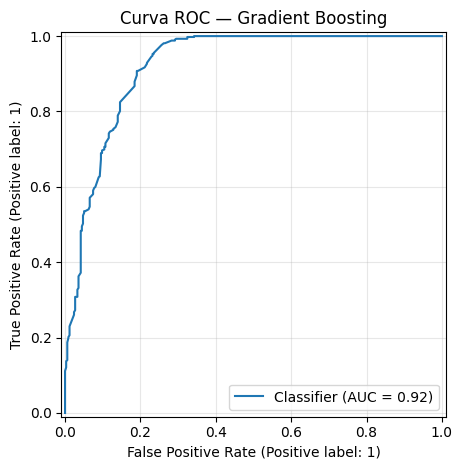

✅ Métricas salvas em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\reports\metricas_modelo.json


In [52]:
melhor_nome = resultados_modelos.iloc[0]["modelo"]
melhor_modelo = pipelines[melhor_nome]

print("🏆 Melhor modelo:", melhor_nome)

y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

matriz = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(
    matriz,
    index=["Real 0 - Sem risco", "Real 1 - Com risco"],
    columns=["Previsto 0 - Sem risco", "Previsto 1 - Com risco"]
))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"Curva ROC — {melhor_nome}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_curva_roc_modelo.png", dpi=150)
plt.show()

metricas_finais = {
    "modelo": melhor_nome,
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred)),
    "recall": float(recall_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "features": features
}

with open(REPORTS_DIR / "metricas_modelo.json", "w", encoding="utf-8") as f:
    json.dump(metricas_finais, f, ensure_ascii=False, indent=4)

print("✅ Métricas salvas em:", REPORTS_DIR / "metricas_modelo.json")

## 17. Importância das variáveis

,feature,importancia
127,DIF_PSICOPEDAGOGICO_NIVEL_-2.5,0.115
116,DIF_PSICOPEDAGOGICO_NIVEL_-1.875,0.078
1,IEG,0.073
373,FASE_FASE 8,0.052
138,DIF_PSICOPEDAGOGICO_NIVEL_-3.125,0.047
122,DIF_PSICOPEDAGOGICO_NIVEL_-2.1875,0.045
5,MEDIA_INDICADORES_SEM_IAN,0.041
106,DIF_PSICOPEDAGOGICO_NIVEL_-1.25,0.038
152,DIF_PSICOPEDAGOGICO_NIVEL_-4.375,0.030
110,DIF_PSICOPEDAGOGICO_NIVEL_-1.5625,0.026


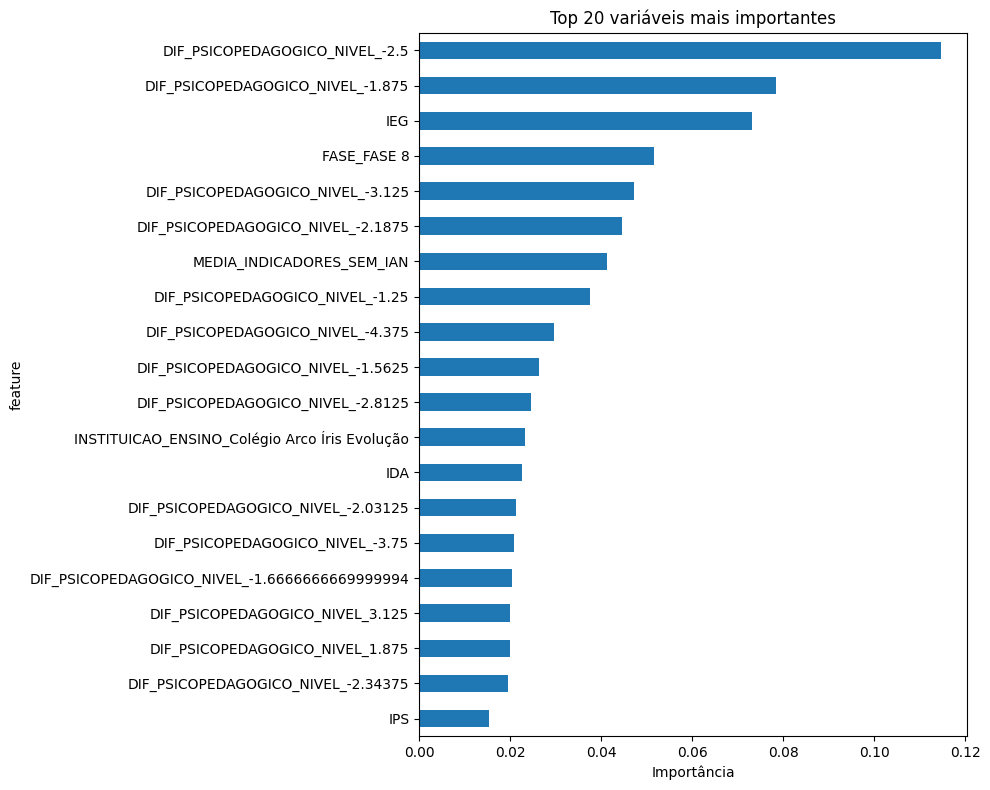

In [53]:
def obter_feature_names(preprocessador, variaveis_numericas, variaveis_categoricas):
    nomes = []
    nomes.extend(variaveis_numericas)
    try:
        onehot = preprocessador.named_transformers_["cat"].named_steps["onehot"]
        nomes_cat = list(onehot.get_feature_names_out(variaveis_categoricas))
        nomes.extend(nomes_cat)
    except Exception:
        pass
    return nomes


modelo_estimador = melhor_modelo.named_steps["modelo"]
preproc_fitado = melhor_modelo.named_steps["preprocessador"]
feature_names = obter_feature_names(preproc_fitado, variaveis_numericas, variaveis_categoricas)

if hasattr(modelo_estimador, "feature_importances_"):
    importancias = pd.DataFrame({
        "feature": feature_names,
        "importancia": modelo_estimador.feature_importances_
    }).sort_values("importancia", ascending=False)

    display(importancias.head(30))

    importancias.head(20).sort_values("importancia").plot(
        x="feature",
        y="importancia",
        kind="barh",
        figsize=(10, 8),
        legend=False
    )
    plt.title("Top 20 variáveis mais importantes")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "09_importancia_variaveis.png", dpi=150)
    plt.show()

    importancias.to_csv(REPORTS_DIR / "importancia_variaveis.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")
else:
    print("O modelo escolhido não possui feature_importances_.")

## 18. Ranking de risco por aluno

In [54]:
base_scored = base.copy()
base_scored["PROB_RISCO_DEFASAGEM"] = melhor_modelo.predict_proba(X)[:, 1]
base_scored["CLASSIFICACAO_RISCO_MODELO"] = pd.cut(
    base_scored["PROB_RISCO_DEFASAGEM"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Baixo", "Médio", "Alto"]
)

colunas_risco = [
    "ANO", "RA", "NOME", "FASE", "TURMA", "GENERO",
    "IDA", "IEG", "IPS", "IPP", "IAA", "IPV",
    "PROB_RISCO_DEFASAGEM", "CLASSIFICACAO_RISCO_MODELO",
    "RISCO_DEFASAGEM", "IAN", "DEFASAGEM"
]

colunas_risco = [c for c in colunas_risco if c in base_scored.columns]
ranking_risco = base_scored[colunas_risco].sort_values("PROB_RISCO_DEFASAGEM", ascending=False)

display(ranking_risco.head(30))

arquivo_ranking = PROCESSED_DIR / "ranking_risco_defasagem.csv"
ranking_risco.to_csv(arquivo_ranking, sep=";", index=False, encoding="utf-8-sig", decimal=",")
print("✅ Ranking salvo em:", arquivo_ranking)

,ANO,RA,NOME,FASE,TURMA,GENERO,IDA,IEG,IPS,IPP,IAA,IPV,PROB_RISCO_DEFASAGEM,CLASSIFICACAO_RISCO_MODELO,RISCO_DEFASAGEM,IAN,DEFASAGEM
1174,2023,RA-679,NaN,FASE 1,1J,Masculino,3.600,7.500,5.020,6.875,7.500,7.393,0.906,Alto,1,5.000,-1.000
1231,2023,RA-772,NaN,FASE 1,1N,Masculino,4.800,7.200,7.520,6.875,0.000,8.003,0.901,Alto,1,5.000,-2.000
1163,2023,RA-1049,NaN,FASE 1,1H,Masculino,6.300,7.700,7.520,8.125,10.000,7.943,0.895,Alto,1,5.000,-1.000
1161,2023,RA-570,NaN,FASE 1,1H,Feminino,5.900,7.300,3.770,8.125,8.500,8.057,0.895,Alto,1,5.000,-1.000
1209,2023,RA-594,NaN,FASE 1,1L,Masculino,5.800,7.100,6.270,6.875,8.500,7.337,0.894,Alto,1,5.000,-1.000
1141,2023,RA-1041,NaN,FASE 1,1F,Feminino,3.300,7.200,7.520,7.812,10.000,8.003,0.892,Alto,1,5.000,-1.000
1186,2023,RA-776,NaN,FASE 1,1K,Feminino,3.500,7.000,7.520,7.812,0.000,7.223,0.892,Alto,1,5.000,-1.000
1173,2023,RA-549,NaN,FASE 1,1J,Masculino,6.400,8.100,5.020,6.875,9.500,7.500,0.889,Alto,1,5.000,-1.000
1060,2023,RA-703,NaN,ALFA,ALFA T - G2/G3,Masculino,4.600,8.400,3.140,6.875,9.500,6.160,0.887,Alto,1,5.000,-2.000
1239,2023,RA-1069,NaN,FASE 1,1P,Masculino,7.100,7.800,7.520,8.125,9.000,8.227,0.884,Alto,1,5.000,-1.000


✅ Ranking salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\data\processed\ranking_risco_defasagem.csv


## 19. Pergunta 10 — Efetividade do programa

,ANO,alunos,INDE_medio,IDA_medio,IEG_medio,IAA_medio,IPS_medio,IPP_medio,IPV_medio,IAN_medio,DEFASAGEM_media,risco_defasagem_pct
0,2022,860,7.036,6.093,7.891,8.274,6.905,NaN,7.254,6.424,NaN,0.699
1,2023,1014,7.356,6.663,8.699,6.903,5.120,7.563,8.028,7.244,-0.655,0.544
2,2024,1156,7.393,6.351,7.375,8.544,6.830,7.548,7.354,7.684,-0.409,0.462


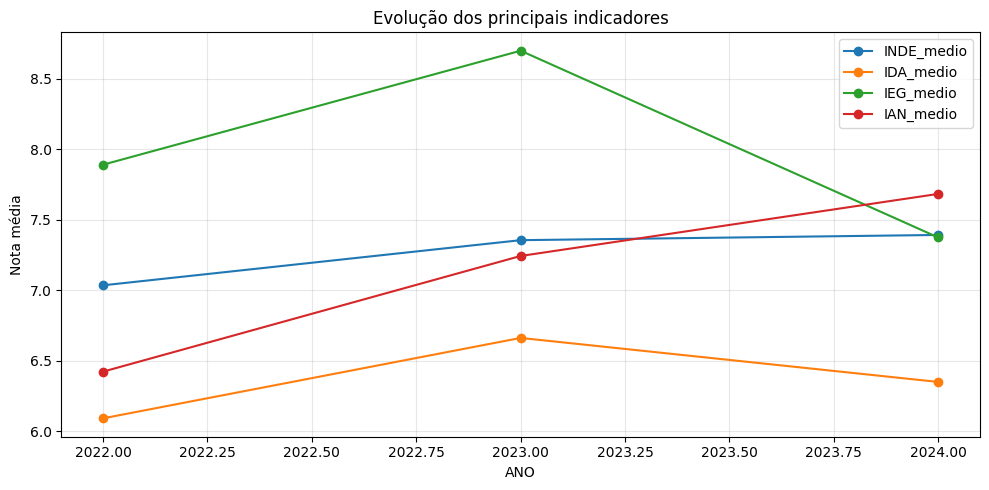

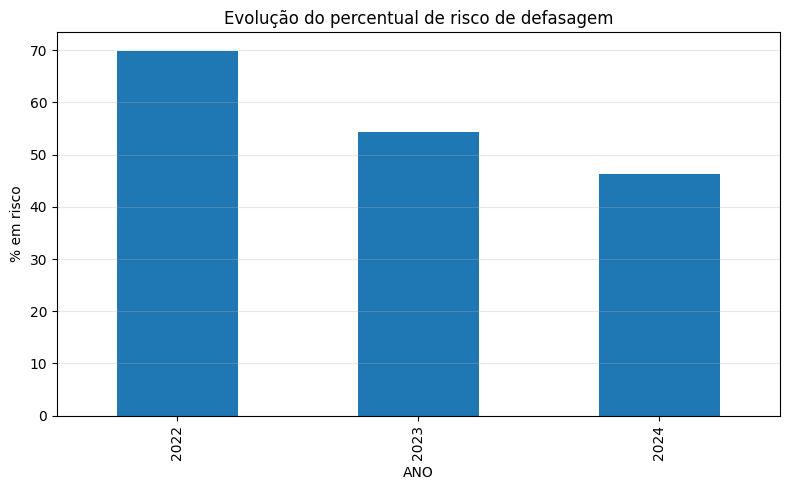

In [55]:
resumo_anual = (
    base.groupby("ANO")
    .agg(
        alunos=("RA", "nunique"),
        INDE_medio=("INDE", "mean"),
        IDA_medio=("IDA", "mean"),
        IEG_medio=("IEG", "mean"),
        IAA_medio=("IAA", "mean"),
        IPS_medio=("IPS", "mean"),
        IPP_medio=("IPP", "mean"),
        IPV_medio=("IPV", "mean"),
        IAN_medio=("IAN", "mean"),
        DEFASAGEM_media=("DEFASAGEM", "mean"),
        risco_defasagem_pct=("RISCO_DEFASAGEM", "mean")
    )
    .round(3)
    .reset_index()
)

display(resumo_anual)

resumo_anual.to_csv(REPORTS_DIR / "resumo_anual.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")

resumo_anual.set_index("ANO")[["INDE_medio", "IDA_medio", "IEG_medio", "IAN_medio"]].plot(marker="o", figsize=(10, 5))
plt.title("Evolução dos principais indicadores")
plt.ylabel("Nota média")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_evolucao_indicadores.png", dpi=150)
plt.show()

(resumo_anual.set_index("ANO")["risco_defasagem_pct"] * 100).plot(kind="bar", figsize=(8, 5))
plt.title("Evolução do percentual de risco de defasagem")
plt.ylabel("% em risco")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_risco_defasagem_ano.png", dpi=150)
plt.show()

✅ Coluna usada para Pedra/Fase: PEDRA_2023
✅ Coluna usada para contar alunos: RA


,ANO,PEDRA_ANALISE,alunos,INDE_medio,risco_pct
0,2022,nan,860,7.036,69.900
4,2023,Topázio,232,8.235,30.200
2,2023,Ametista,381,7.474,57.500
5,2023,nan,83,7.306,9.600
1,2023,Agata,246,6.726,77.600
3,2023,Quartzo,72,6.072,88.900
6,2024,nan,1156,7.393,46.200


PEDRA_ANALISE,Agata,Ametista,Quartzo,Topázio,nan
ANO,,,,,
2022,0.000,0.000,0.000,0.000,860.000
2023,246.000,381.000,72.000,232.000,83.000
2024,0.000,0.000,0.000,0.000,"1,156.000"


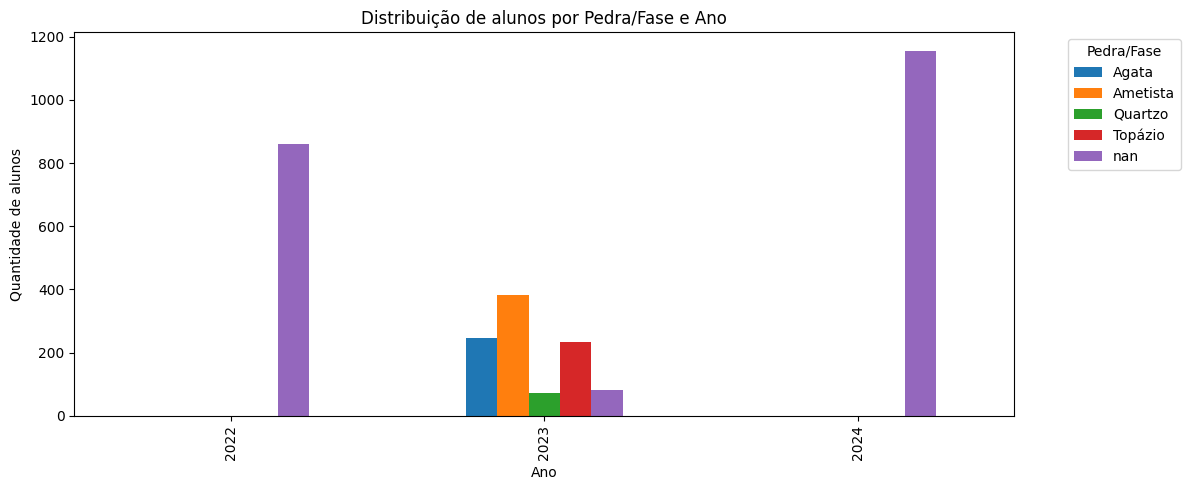

In [56]:
# ============================================================
# ANÁLISE POR PEDRA / FASE
# Versão ajustada para evitar KeyError: PEDRA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Localizar coluna PEDRA ou equivalente
# ------------------------------------------------------------

def localizar_coluna_segura(df, opcoes):
    for opcao in opcoes:
        if opcao in df.columns:
            return opcao

    for col in df.columns:
        col_norm = str(col).upper().replace(" ", "_")
        for opcao in opcoes:
            opcao_norm = str(opcao).upper().replace(" ", "_")
            if opcao_norm in col_norm:
                return col

    return None


col_pedra = localizar_coluna_segura(
    base,
    [
        "PEDRA",
        "PEDRA_2022",
        "PEDRA_2023",
        "PEDRA_2024",
        "INDE_PEDRA",
        "CLASSIFICACAO_PEDRA",
        "CLASSIFICAÇÃO_PEDRA",
        "FASE",
        "NIVEL",
        "NÍVEL"
    ]
)

if col_pedra:
    print(f"✅ Coluna usada para Pedra/Fase: {col_pedra}")
    base["PEDRA_ANALISE"] = base[col_pedra].astype(str).str.strip()
else:
    print("⚠️ Nenhuma coluna de Pedra/Fase encontrada. Criando como 'Não informado'.")
    base["PEDRA_ANALISE"] = "Não informado"


# ------------------------------------------------------------
# Localizar coluna de aluno
# ------------------------------------------------------------

col_aluno = localizar_coluna_segura(
    base,
    ["RA", "ID_ALUNO", "COD_ALUNO", "ALUNO", "NOME"]
)

if col_aluno:
    print(f"✅ Coluna usada para contar alunos: {col_aluno}")
else:
    print("⚠️ Nenhuma coluna de aluno encontrada. Será usada contagem de linhas.")


# ------------------------------------------------------------
# Garantir colunas necessárias
# ------------------------------------------------------------

if "INDE" not in base.columns:
    print("⚠️ Coluna INDE não encontrada. INDE_medio será ignorado.")

if "RISCO_DEFASAGEM" not in base.columns:
    print("⚠️ Coluna RISCO_DEFASAGEM não encontrada. risco_pct será ignorado.")


# ------------------------------------------------------------
# Montar agregações dinamicamente
# ------------------------------------------------------------

agg_dict = {}

if col_aluno:
    agg_dict["alunos"] = (col_aluno, "nunique")
else:
    agg_dict["alunos"] = ("ANO", "size")

if "INDE" in base.columns:
    agg_dict["INDE_medio"] = ("INDE", "mean")

if "RISCO_DEFASAGEM" in base.columns:
    agg_dict["risco_pct"] = ("RISCO_DEFASAGEM", "mean")


pedra_ano = (
    base.groupby(["ANO", "PEDRA_ANALISE"])
    .agg(**agg_dict)
    .round(3)
    .reset_index()
)

if "INDE_medio" in pedra_ano.columns:
    pedra_ano = pedra_ano.sort_values(
        ["ANO", "INDE_medio"],
        ascending=[True, False]
    )
else:
    pedra_ano = pedra_ano.sort_values(["ANO", "alunos"], ascending=[True, False])

if "risco_pct" in pedra_ano.columns:
    pedra_ano["risco_pct"] = (pedra_ano["risco_pct"] * 100).round(2)

display(pedra_ano)


# ------------------------------------------------------------
# Tabela dinâmica de alunos por pedra/fase
# ------------------------------------------------------------

tabela_pedra = (
    pedra_ano
    .pivot(index="ANO", columns="PEDRA_ANALISE", values="alunos")
    .fillna(0)
)

display(tabela_pedra)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

tabela_pedra.plot(kind="bar", figsize=(12, 5))

plt.title("Distribuição de alunos por Pedra/Fase e Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")
plt.legend(title="Pedra/Fase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 20. Pergunta 11 — Insights adicionais

In [57]:
alto_eng_baixo_desempenho = base[(base["IEG"] >= 7) & (base["IDA"] < 6)].copy()
auto_alta_desempenho_baixo = base[(base["IAA"] >= 8) & (base["IDA"] < 6)].copy()
risco_alto_modelo = base_scored[base_scored["CLASSIFICACAO_RISCO_MODELO"] == "Alto"].copy()

print("Alto engajamento e baixo desempenho:", len(alto_eng_baixo_desempenho))
display(alto_eng_baixo_desempenho[["ANO", "RA", "FASE", "TURMA", "IEG", "IDA", "IPS", "IPP", "IAN", "DEFASAGEM"]].head(20))

print("Autoavaliação alta e desempenho baixo:", len(auto_alta_desempenho_baixo))
display(auto_alta_desempenho_baixo[["ANO", "RA", "FASE", "TURMA", "IAA", "IDA", "IEG", "IPS", "IPP", "IAN", "DEFASAGEM"]].head(20))

print("Risco alto previsto pelo modelo:", len(risco_alto_modelo))
display(risco_alto_modelo[colunas_risco].head(20))

alto_eng_baixo_desempenho.to_csv(PROCESSED_DIR / "insight_alto_engajamento_baixo_desempenho.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")
auto_alta_desempenho_baixo.to_csv(PROCESSED_DIR / "insight_autoavaliacao_alta_desempenho_baixo.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")
risco_alto_modelo.to_csv(PROCESSED_DIR / "insight_alunos_risco_alto_modelo.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")

Alto engajamento e baixo desempenho: 680


,ANO,RA,FASE,TURMA,IEG,IDA,IPS,IPP,IAN,DEFASAGEM
2,2022,RA-3,7,A,7.900,5.600,5.600,NaN,10.000,NaN
4,2022,RA-5,7,A,8.600,5.200,5.600,NaN,10.000,NaN
12,2022,RA-13,7,A,7.400,4.700,7.500,NaN,5.000,NaN
13,2022,RA-14,7,D,8.300,4.000,7.500,NaN,5.000,NaN
15,2022,RA-16,7,D,8.300,3.500,5.000,NaN,5.000,NaN
20,2022,RA-21,7,D,9.200,3.800,7.500,NaN,5.000,NaN
41,2022,RA-42,5,A,7.900,4.800,5.600,NaN,10.000,NaN
45,2022,RA-46,5,A,8.400,2.100,6.300,NaN,5.000,NaN
48,2022,RA-49,5,A,7.400,3.900,7.500,NaN,5.000,NaN
50,2022,RA-51,5,B,7.600,5.000,7.500,NaN,5.000,NaN


Autoavaliação alta e desempenho baixo: 683


,ANO,RA,FASE,TURMA,IAA,IDA,IEG,IPS,IPP,IAN,DEFASAGEM
0,2022,RA-1,7,A,8.300,4.000,4.100,5.600,NaN,5.000,NaN
3,2022,RA-4,7,A,8.800,5.000,4.500,5.600,NaN,10.000,NaN
9,2022,RA-10,7,A,8.300,4.100,5.200,5.000,NaN,5.000,NaN
10,2022,RA-11,7,A,9.200,3.000,4.200,5.000,NaN,5.000,NaN
20,2022,RA-21,7,D,9.600,3.800,9.200,7.500,NaN,5.000,NaN
33,2022,RA-34,6,A,9.600,3.800,4.800,8.100,NaN,5.000,NaN
40,2022,RA-41,5,A,9.200,5.600,6.100,5.000,NaN,5.000,NaN
41,2022,RA-42,5,A,8.300,4.800,7.900,5.600,NaN,10.000,NaN
45,2022,RA-46,5,A,8.800,2.100,8.400,6.300,NaN,5.000,NaN
50,2022,RA-51,5,B,8.800,5.000,7.600,7.500,NaN,5.000,NaN


Risco alto previsto pelo modelo: 1959


,ANO,RA,NOME,FASE,TURMA,GENERO,IDA,IEG,IPS,IPP,IAA,IPV,PROB_RISCO_DEFASAGEM,CLASSIFICACAO_RISCO_MODELO,RISCO_DEFASAGEM,IAN,DEFASAGEM
0,2022,RA-1,Aluno-1,7,A,Feminino,4.000,4.100,5.600,NaN,8.300,7.278,0.778,Alto,1,5.000,NaN
1,2022,RA-2,Aluno-2,7,A,Feminino,6.800,5.200,6.300,NaN,8.800,6.778,0.737,Alto,0,10.000,NaN
2,2022,RA-3,Aluno-3,7,A,Feminino,5.600,7.900,5.600,NaN,0.000,7.556,0.746,Alto,0,10.000,NaN
3,2022,RA-4,Aluno-4,7,A,Masculino,5.000,4.500,5.600,NaN,8.800,5.278,0.746,Alto,0,10.000,NaN
4,2022,RA-5,Aluno-5,7,A,Feminino,5.200,8.600,5.600,NaN,7.900,7.389,0.708,Alto,0,10.000,NaN
5,2022,RA-6,Aluno-6,7,A,Feminino,3.300,4.500,7.500,NaN,7.900,7.222,0.778,Alto,1,5.000,NaN
6,2022,RA-7,Aluno-7,7,A,Masculino,7.600,8.400,7.500,NaN,0.000,7.667,0.680,Alto,1,5.000,NaN
7,2022,RA-8,Aluno-8,7,A,Feminino,1.600,4.600,6.300,NaN,7.100,6.278,0.778,Alto,1,5.000,NaN
8,2022,RA-9,Aluno-9,7,A,Feminino,6.700,9.500,7.500,NaN,8.800,9.500,0.672,Alto,1,5.000,NaN
9,2022,RA-10,Aluno-10,7,A,Feminino,4.100,5.200,5.000,NaN,8.300,7.056,0.778,Alto,1,5.000,NaN


## 21. Roteiro de storytelling gerencial

In [58]:
roteiro = f"""
# Storytelling — Datathon Passos Mágicos

## 1. Contexto

A Associação Passos Mágicos atua para transformar a vida de crianças e jovens em vulnerabilidade social por meio da educação, apoio psicossocial, apoio psicopedagógico e desenvolvimento do protagonismo.

## 2. Base analisada

Foram analisados dados de 2022, 2023 e 2024.

Resumo anual:

{resumo_anual.to_markdown(index=False)}

## 3. Principais achados

### Defasagem e IAN

A análise do IAN e da defasagem permite segmentar alunos por adequação de nível.
Alunos com defasagem negativa ou IAN baixo foram classificados como risco de defasagem.

### Desempenho acadêmico

O IDA foi usado como indicador central de desempenho acadêmico, complementado pelas notas de matemática, português e inglês.

### Engajamento

O IEG foi analisado com IDA e IPV.
Alunos com bom engajamento e baixo desempenho representam grupo com alta possibilidade de recuperação mediante intervenção acadêmica direcionada.

### Autoavaliação

A diferença entre IAA e IDA mostra desalinhamentos entre percepção do aluno e desempenho real.
Quando a autoavaliação é alta e o desempenho é baixo, pode haver necessidade de devolutivas pedagógicas mais claras.

### Aspectos psicossociais e psicopedagógicos

IPS e IPP ajudam a identificar fatores não exclusivamente acadêmicos.
Esses indicadores podem anteceder quedas de desempenho ou engajamento.

## 4. Modelo preditivo

Foi construído um modelo de classificação para prever risco de defasagem.

Alvo:
- risco = 1 quando DEFASAGEM < 0 ou IAN <= 5;
- risco = 0 nos demais casos.

Para evitar vazamento de dados, IAN, DEFASAGEM, INDE e PEDRA não foram usados como variáveis explicativas.

Métricas finais:

{json.dumps(metricas_finais, ensure_ascii=False, indent=4)}

## 5. Recomendações

1. Priorizar alunos com maior probabilidade de risco.
2. Criar plano de intervenção por perfil: acadêmico, engajamento, psicossocial e psicopedagógico.
3. Acompanhar evolução anual dos indicadores.
4. Usar o app Streamlit como ferramenta de triagem.
5. Validar os alertas do modelo com a equipe pedagógica.

## 6. Conclusão

A análise mostra que os indicadores podem ser usados para antecipar riscos, orientar intervenções e apoiar decisões da Passos Mágicos com base em dados.
"""

arquivo_roteiro = REPORTS_DIR / "roteiro_storytelling.md"
with open(arquivo_roteiro, "w", encoding="utf-8") as f:
    f.write(roteiro)

print("✅ Roteiro salvo em:", arquivo_roteiro)
print(roteiro[:3000])

✅ Roteiro salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\reports\roteiro_storytelling.md

# Storytelling — Datathon Passos Mágicos

## 1. Contexto

A Associação Passos Mágicos atua para transformar a vida de crianças e jovens em vulnerabilidade social por meio da educação, apoio psicossocial, apoio psicopedagógico e desenvolvimento do protagonismo.

## 2. Base analisada

Foram analisados dados de 2022, 2023 e 2024.

Resumo anual:

|   ANO |   alunos |   INDE_medio |   IDA_medio |   IEG_medio |   IAA_medio |   IPS_medio |   IPP_medio |   IPV_medio |   IAN_medio |   DEFASAGEM_media |   risco_defasagem_pct |
|------:|---------:|-------------:|------------:|------------:|------------:|------------:|------------:|------------:|------------:|------------------:|----------------------:|
|  2022 |      860 |        7.036 |       6.093 |       7.891 |       8.274 |       6.905 |     nan  

## 22. Salvamento do modelo e metadados

In [59]:
arquivo_modelo = MODELS_DIR / "modelo_risco_defasagem.pkl"
arquivo_features = MODELS_DIR / "features.json"

joblib.dump(melhor_modelo, arquivo_modelo)

with open(arquivo_features, "w", encoding="utf-8") as f:
    json.dump({
        "features": features,
        "variaveis_numericas": variaveis_numericas,
        "variaveis_categoricas": variaveis_categoricas,
        "target": target,
        "modelo": melhor_nome
    }, f, ensure_ascii=False, indent=4)

print("✅ Modelo salvo em:", arquivo_modelo)
print("✅ Features salvas em:", arquivo_features)

✅ Modelo salvo em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\models\modelo_risco_defasagem.pkl
✅ Features salvas em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\models\features.json


## 23. Geração opcional do app Streamlit

In [60]:
app_code = """
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st

BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = BASE_DIR / "models" / "modelo_risco_defasagem.pkl"
FEATURES_PATH = BASE_DIR / "models" / "features.json"

st.set_page_config(
    page_title="Passos Mágicos — Risco de Defasagem",
    page_icon="✨",
    layout="wide"
)

st.title("✨ Passos Mágicos — Modelo Preditivo de Risco de Defasagem")
st.write("Aplicação para estimar a probabilidade de risco de defasagem com base nos indicadores educacionais.")

@st.cache_resource
def carregar_modelo():
    modelo = joblib.load(MODEL_PATH)
    with open(FEATURES_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)
    return modelo, meta

modelo, meta = carregar_modelo()
features = meta["features"]

st.sidebar.header("Entrada dos indicadores")

idade = st.sidebar.number_input("Idade", min_value=5, max_value=30, value=12)
ano_ingresso = st.sidebar.number_input("Ano de ingresso", min_value=1990, max_value=2030, value=2022)

ano = st.sidebar.selectbox("Ano", [2022, 2023, 2024])
fase = st.sidebar.text_input("Fase", "ALFA")
turma = st.sidebar.text_input("Turma", "ALFA A - G0/G1")
genero = st.sidebar.selectbox("Gênero", ["Feminino", "Masculino", "Outro"])
instituicao = st.sidebar.selectbox("Instituição de ensino", ["Pública", "Particular", "Outro"])

iaa = st.sidebar.slider("IAA — Autoavaliação", 0.0, 10.0, 7.0, 0.1)
ieg = st.sidebar.slider("IEG — Engajamento", 0.0, 10.0, 7.0, 0.1)
ips = st.sidebar.slider("IPS — Psicossocial", 0.0, 10.0, 7.0, 0.1)
ipp = st.sidebar.slider("IPP — Psicopedagógico", 0.0, 10.0, 7.0, 0.1)
ida = st.sidebar.slider("IDA — Desempenho acadêmico", 0.0, 10.0, 7.0, 0.1)
matematica = st.sidebar.slider("Matemática", 0.0, 10.0, 7.0, 0.1)
portugues = st.sidebar.slider("Português", 0.0, 10.0, 7.0, 0.1)
ingles = st.sidebar.slider("Inglês", 0.0, 10.0, 7.0, 0.1)
ipv = st.sidebar.slider("IPV — Ponto de Virada", 0.0, 10.0, 7.0, 0.1)

entrada = {
    "IDADE": idade,
    "ANO_INGRESSO": ano_ingresso,
    "IAA": iaa,
    "IEG": ieg,
    "IPS": ips,
    "IPP": ipp,
    "IDA": ida,
    "MATEMATICA": matematica,
    "PORTUGUES": portugues,
    "INGLES": ingles,
    "IPV": ipv,
    "DIF_AUTOAVALIACAO_DESEMPENHO": iaa - ida,
    "DIF_ENGAJAMENTO_DESEMPENHO": ieg - ida,
    "MEDIA_INDICADORES_SEM_IAN": np.mean([iaa, ieg, ips, ipp, ida, ipv]),
    "QTD_INDICADORES_ABAIXO_5": sum(np.array([iaa, ieg, ips, ipp, ida, ipv]) < 5),
    "QTD_INDICADORES_ABAIXO_7": sum(np.array([iaa, ieg, ips, ipp, ida, ipv]) < 7),
    "ANO": ano,
    "FASE": fase,
    "TURMA": turma,
    "GENERO": genero,
    "INSTITUICAO_ENSINO": instituicao,
}

df_entrada = pd.DataFrame([entrada])

for col in features:
    if col not in df_entrada.columns:
        df_entrada[col] = np.nan

df_entrada = df_entrada[features]

prob = modelo.predict_proba(df_entrada)[0, 1]

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Probabilidade de risco", f"{prob * 100:.1f}%")

with col2:
    if prob >= 0.60:
        classe = "Alto"
    elif prob >= 0.30:
        classe = "Médio"
    else:
        classe = "Baixo"
    st.metric("Classificação", classe)

with col3:
    st.metric("Modelo", meta.get("modelo", "Modelo treinado"))

if prob >= 0.60:
    st.error("Aluno em risco alto. Recomenda-se intervenção prioritária.")
elif prob >= 0.30:
    st.warning("Aluno em risco médio. Recomenda-se acompanhamento.")
else:
    st.success("Aluno em risco baixo. Manter acompanhamento regular.")

st.subheader("Dados informados")
st.dataframe(df_entrada)

st.subheader("Como interpretar")
st.write(
    "O modelo estima risco com base em indicadores acadêmicos, engajamento, autoavaliação e aspectos psicossociais/psicopedagógicos. A previsão deve ser usada como apoio à decisão, não como decisão automática."
)
"""

arquivo_app = APP_DIR / "app_streamlit.py"

with open(arquivo_app, "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ App Streamlit criado em:", arquivo_app)
print("Para executar localmente:")
print(f"streamlit run {arquivo_app}")

✅ App Streamlit criado em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\app\app_streamlit.py
Para executar localmente:
streamlit run C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\app\app_streamlit.py


## 24. Requirements

In [61]:
requirements = """
pandas
numpy
matplotlib
scikit-learn
openpyxl
joblib
streamlit
"""

arquivo_req = BASE_DIR / "requirements.txt"

with open(arquivo_req, "w", encoding="utf-8") as f:
    f.write(requirements.strip())

print("✅ requirements.txt criado em:", arquivo_req)

✅ requirements.txt criado em: C:\OD Danilo\OneDrive - ALBIERI E ASSOCIADOS CONSULTORIA EMPRESARIAL LTDA\Documentos\Fiap_Data Analitics\TC_Fase 5\tech_challenge_passos_magicos\requirements.txt


## 25. Conclusão

Com este notebook você terá:

- base tratada consolidada;
- gráficos para storytelling;
- respostas analíticas às 11 perguntas;
- modelo preditivo treinado e avaliado;
- ranking de alunos por risco;
- roteiro gerencial;
- app Streamlit gerado;
- arquivos prontos para GitHub e entrega.